In [1]:
# %%
# 1) Load JSON and build a long-form table of (pid, day, mood, completed_today, next_complete)

import json
from pathlib import Path
import numpy as np
import pandas as pd

# Path to your dataset
JSON_PATH = "participants_data.json"

# Load JSON
with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

def parse_day_key(k):
    """
    Parse day keys like "Day 4" / "day 4" / "4" into integer 4.
    Return None if parsing fails.
    """
    if k is None:
        return None
    s = str(k).strip()
    if s.lower().startswith("day "):
        s = s.split(" ", 1)[1].strip()
    try:
        return int(s)
    except Exception:
        return None

records = []
demo_rows = []

for pid, node in data.items():
    demo = node.get("Demographic", {}) or {}
    mood_map = node.get("Mood", {}) or {}

    # Normalize mood to (int day, float value/NaN)
    mood_kv = []
    for k, v in mood_map.items():
        d = parse_day_key(k)
        if d is None:
            continue
        try:
            mv = float(v)
        except Exception:
            mv = np.nan
        mood_kv.append((d, mv))

    # Even if no mood rows, keep demographics
    if not mood_kv:
        demo_rows.append({"pid": pid, **demo})
        continue

    mood_df = pd.DataFrame(mood_kv, columns=["day", "mood"]).sort_values("day", ignore_index=True)
    min_day, max_day = int(mood_df["day"].min()), int(mood_df["day"].max())

    # Participant-specific window [min_day .. max_day]
    all_days = pd.DataFrame({"day": np.arange(min_day, max_day + 1, dtype=int)})

    # If you prefer a fixed study window (e.g., 0..120), replace the above with:
    # D_FIXED = 120
    # all_days = pd.DataFrame({"day": np.arange(0, D_FIXED + 1, dtype=int)})

    df = all_days.merge(mood_df, on="day", how="left")

    # Whether a mood was completed today
    df["completed_today"] = (~df["mood"].isna()).astype(int)

    # Whether next day's mood is completed (lookahead by one day)
    df["next_complete"] = df["completed_today"].shift(-1).fillna(0).astype(int)

    # Attach demographics
    for col, val in demo.items():
        df[col] = val

    df["pid"] = pid
    records.append(df)
    demo_rows.append({"pid": pid, **demo})

# Build final long-form table
if records:
    long = pd.concat(records, ignore_index=True)
    # Arrange columns for readability
    front_cols = ["pid", "day", "mood", "completed_today", "next_complete"]
    other_cols = [c for c in long.columns if c not in front_cols]
    long = long[front_cols + other_cols]
else:
    long = pd.DataFrame(columns=["pid", "day", "mood", "completed_today", "next_complete"])

demo_df = pd.DataFrame(demo_rows)

# Notebook-friendly visibility
print("[OK] long-shape rows:", len(long))
print("[OK] participants with any mood rows:", long["pid"].nunique() if not long.empty else 0)
print("[OK] total participants in JSON:", len(data))

# Show a preview
try:
    from IPython.display import display
    display(long.head(10) if not long.empty else long)
except Exception:
    # Fallback for non-notebook environments
    print(long.head(10) if not long.empty else long)


[OK] long-shape rows: 29139
[OK] participants with any mood rows: 312
[OK] total participants in JSON: 334


,pid,day,mood,completed_today,next_complete,arm,cg_hours,age,gender,monthly_income,transplant_type,dyad_id,role,in_hospital_days
0,P311,4,9.0,1,1,Intervention,Less than or equal to 40 hours,61+,Female,"$1,000 - $2,999",Autologous,1,Caregivers,OHSU patient
1,P311,5,8.0,1,1,Intervention,Less than or equal to 40 hours,61+,Female,"$1,000 - $2,999",Autologous,1,Caregivers,OHSU patient
2,P311,6,6.0,1,0,Intervention,Less than or equal to 40 hours,61+,Female,"$1,000 - $2,999",Autologous,1,Caregivers,OHSU patient
3,P311,7,NaN,0,1,Intervention,Less than or equal to 40 hours,61+,Female,"$1,000 - $2,999",Autologous,1,Caregivers,OHSU patient
4,P311,8,5.0,1,1,Intervention,Less than or equal to 40 hours,61+,Female,"$1,000 - $2,999",Autologous,1,Caregivers,OHSU patient
5,P311,9,6.0,1,1,Intervention,Less than or equal to 40 hours,61+,Female,"$1,000 - $2,999",Autologous,1,Caregivers,OHSU patient
6,P311,10,7.0,1,1,Intervention,Less than or equal to 40 hours,61+,Female,"$1,000 - $2,999",Autologous,1,Caregivers,OHSU patient
7,P311,11,6.0,1,1,Intervention,Less than or equal to 40 hours,61+,Female,"$1,000 - $2,999",Autologous,1,Caregivers,OHSU patient
8,P311,12,7.0,1,1,Intervention,Less than or equal to 40 hours,61+,Female,"$1,000 - $2,999",Autologous,1,Caregivers,OHSU patient
9,P311,13,8.0,1,1,Intervention,Less than or equal to 40 hours,61+,Female,"$1,000 - $2,999",Autologous,1,Caregivers,OHSU patient


[INFO] Participants considered: 334
[INFO] Denominator strategy: all


,day,missing_count,denominator,missing_rate
0,1,154,334,0.461078
1,2,170,334,0.508982
2,3,180,334,0.538922
3,4,172,334,0.514970
4,5,168,334,0.502994
5,6,162,334,0.485030
6,7,165,334,0.494012
7,8,166,334,0.497006
8,9,169,334,0.505988
9,10,175,334,0.523952


,day,missing_count,denominator,missing_rate
110,111,218,334,0.652695
111,112,226,334,0.676647
112,113,212,334,0.634731
113,114,219,334,0.655689
114,115,223,334,0.667665
115,116,214,334,0.640719
116,117,212,334,0.634731
117,118,227,334,0.679641
118,119,225,334,0.673653
119,120,218,334,0.652695


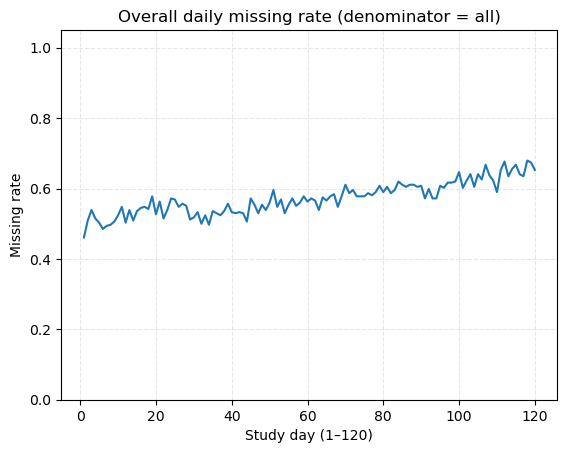

In [2]:
# %%
# Overall per-day MISSING rate (no demographic stratification), days 1..MAX_DAYS
# Data source: participants_data.json
# Assumptions:
#   - node["Mood"] is a map like { "Day 4": 7.0, "Day 5": 8.0, ... } or {"4": 7.0, ...}
#   - "Missing" for a day = absence of a mood value on that day.
#
# Denominator strategy:
#   - "all":      all participants are expected each day (constant denominator = N)
#   - "enrolled": only participants who have any mood day <= current day are expected that day
#
# Output:
#   - summary DataFrame with: day, missing_count, denominator, missing_rate
#   - a simple matplotlib line plot of missing_rate over days 1..MAX_DAYS

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

JSON_PATH = "participants_data.json"
MAX_DAYS  = 120
DENOMINATOR_STRATEGY = "all"     # choose: "all" or "enrolled"
EXPORT_CSV = False               # set True to export summary to CSV
CSV_PATH   = "overall_missing_rate_1_120.csv"

def parse_day_key(k):
    """
    Parse keys like "Day 4" / "day 4" / "4" into integer 4.
    Return None if parsing fails.
    """
    if k is None:
        return None
    s = str(k).strip()
    if s.lower().startswith("day "):
        s = s.split(" ", 1)[1].strip()
    try:
        return int(s)
    except Exception:
        return None

# --------------------
# Load JSON
# --------------------
json_path = Path(JSON_PATH)
if not json_path.exists():
    raise FileNotFoundError(f"JSON not found at: {json_path.resolve()}")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# --------------------
# Collect per-participant completed-day sets (restricted to 1..MAX_DAYS)
# --------------------
all_pids = []
pid_daysets = {}

for pid, node in data.items():
    if not isinstance(node, dict):
        continue
    mood_map = node.get("Mood", {}) or {}
    dset = set()
    for k in mood_map.keys():
        d = parse_day_key(k)
        if d is None:
            continue
        if 1 <= d <= MAX_DAYS:
            dset.add(d)
    pid_daysets[pid] = dset
    all_pids.append(pid)

# Keep only participants for which we created a set (should be all valid entries)
all_pids = [p for p in all_pids if isinstance(pid_daysets.get(p), set)]
num_participants = len(all_pids)

if num_participants == 0:
    # Show a graceful message and an empty frame so the notebook cell still prints something
    print("[INFO] Participants considered: 0")
    summary = pd.DataFrame(columns=["day", "missing_count", "denominator", "missing_rate"])
    try:
        from IPython.display import display
        display(summary)
    except Exception:
        print(summary)
else:
    print(f"[INFO] Participants considered: {num_participants}")

    # --------------------
    # Compute overall per-day missing curve
    # --------------------
    days = np.arange(1, MAX_DAYS + 1, dtype=int)

    # completed count per day
    completed_counts = np.zeros(MAX_DAYS, dtype=np.int32)

    # first observed day for 'enrolled' denominator
    first_obs = np.full(num_participants, np.inf, dtype=float)

    for i, pid in enumerate(all_pids):
        dset = pid_daysets.get(pid, set())
        # mark completions
        for d in dset:
            completed_counts[d - 1] += 1
        # first observed day (if any)
        if len(dset) > 0:
            first_obs[i] = float(min(dset))

    # denominator per day
    if DENOMINATOR_STRATEGY == "all":
        denom = np.full(MAX_DAYS, num_participants, dtype=np.int32)
    elif DENOMINATOR_STRATEGY == "enrolled":
        denom = np.zeros(MAX_DAYS, dtype=np.int32)
        for idx, d in enumerate(days):
            denom[idx] = int(np.sum(first_obs <= d))
        # avoid division by zero
        denom = np.where(denom == 0, 1, denom)
    else:
        raise ValueError("DENOMINATOR_STRATEGY must be 'all' or 'enrolled'.")

    # Missing = denom - completed
    missing_counts = denom - completed_counts
    missing_rate = missing_counts / denom

    summary = pd.DataFrame({
        "day": days,
        "missing_count": missing_counts,
        "denominator": denom,
        "missing_rate": missing_rate
    })

    print(f"[INFO] Denominator strategy: {DENOMINATOR_STRATEGY}")

    # Notebook-friendly preview (with fallback for pure Python)
    try:
        from IPython.display import display
        display(summary.head(10))
        display(summary.tail(10))
    except Exception:
        print(summary.head(10))
        print("...")
        print(summary.tail(10))

    if EXPORT_CSV:
        summary.to_csv(CSV_PATH, index=False)
        print(f"[INFO] Exported to: {Path(CSV_PATH).resolve()}")

    # --------------------
    # Plot (simple)
    # --------------------
    plt.figure()
    plt.plot(summary["day"], summary["missing_rate"])
    plt.xlabel("Study day (1–120)")
    plt.ylabel("Missing rate")
    plt.title(f"Overall daily missing rate (denominator = {DENOMINATOR_STRATEGY})")
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


[INFO] Total participants: 334  |  Patients: 167  |  Caregivers: 167


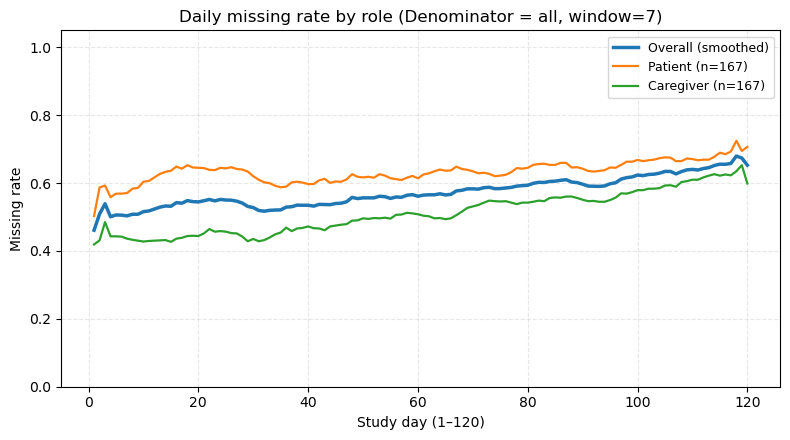

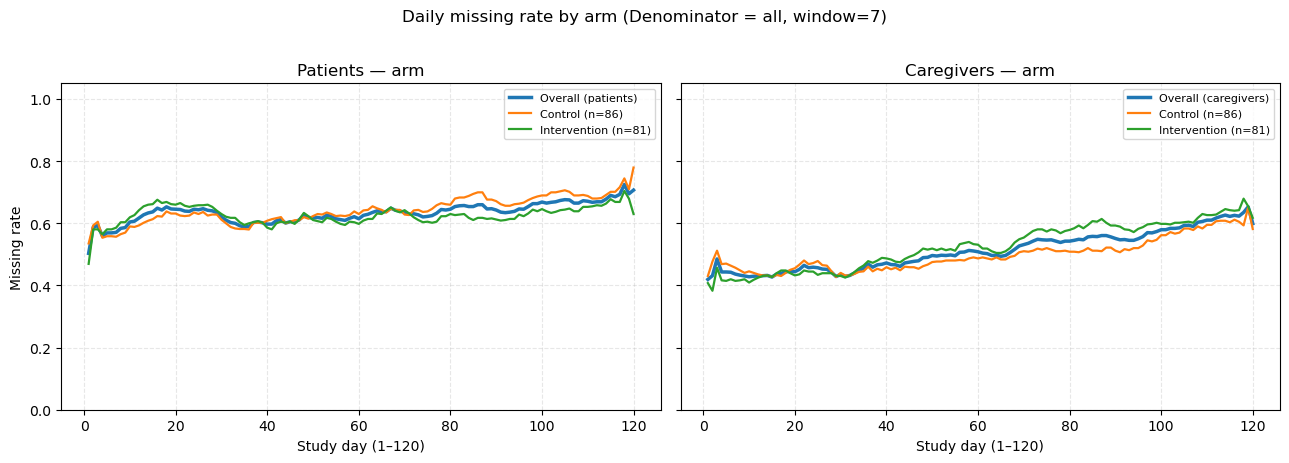

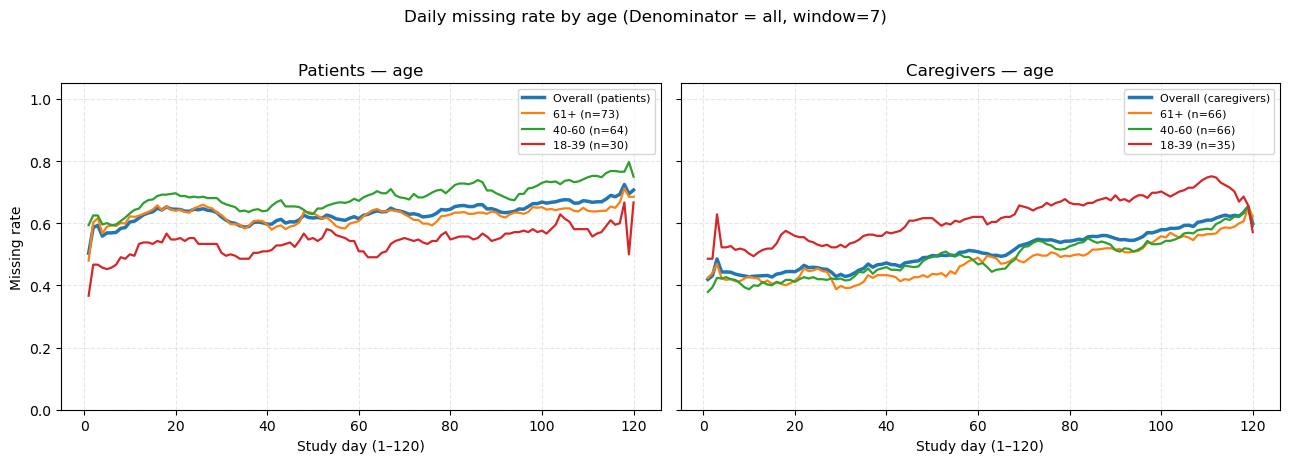

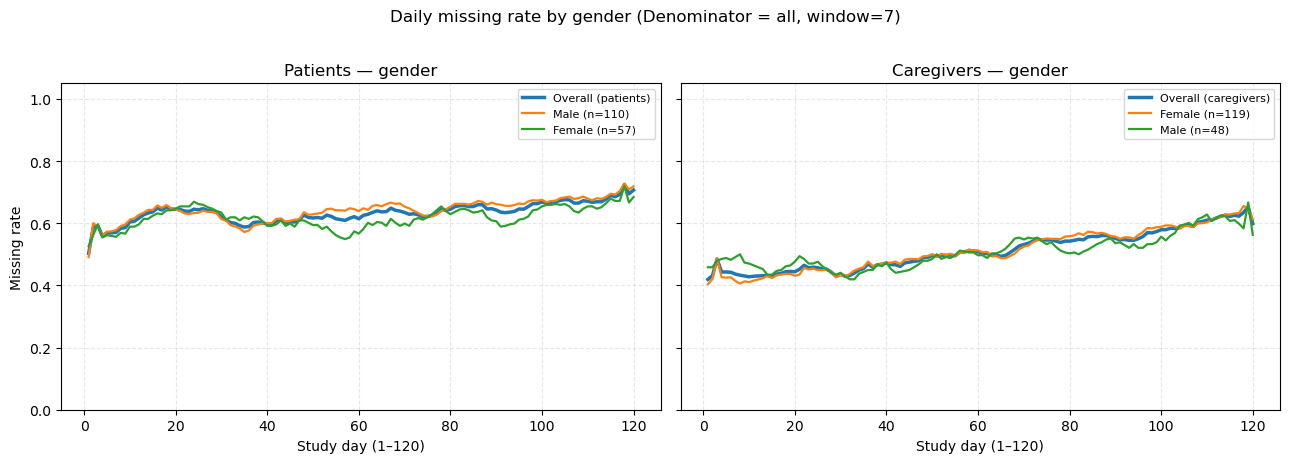

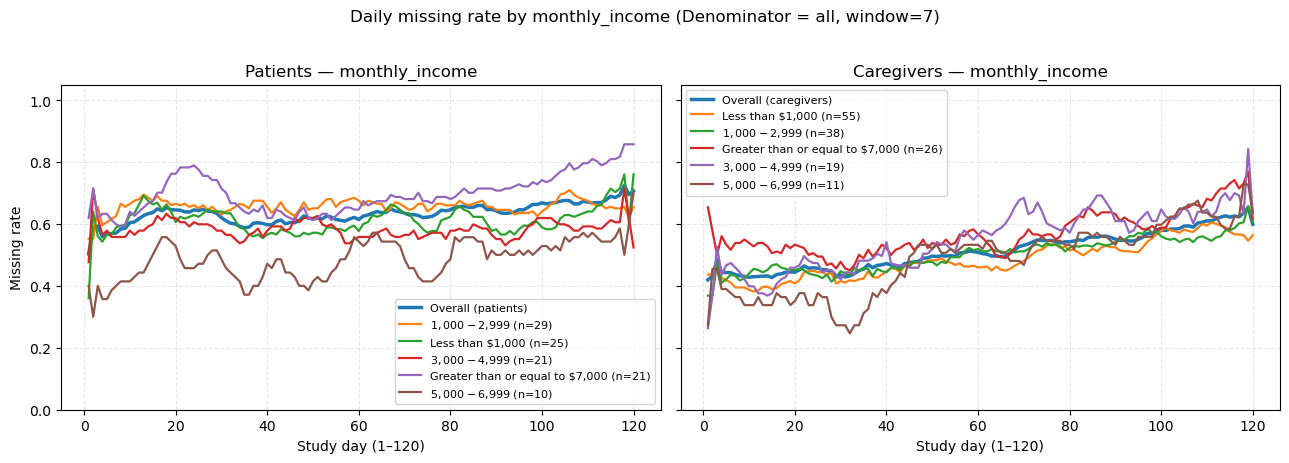

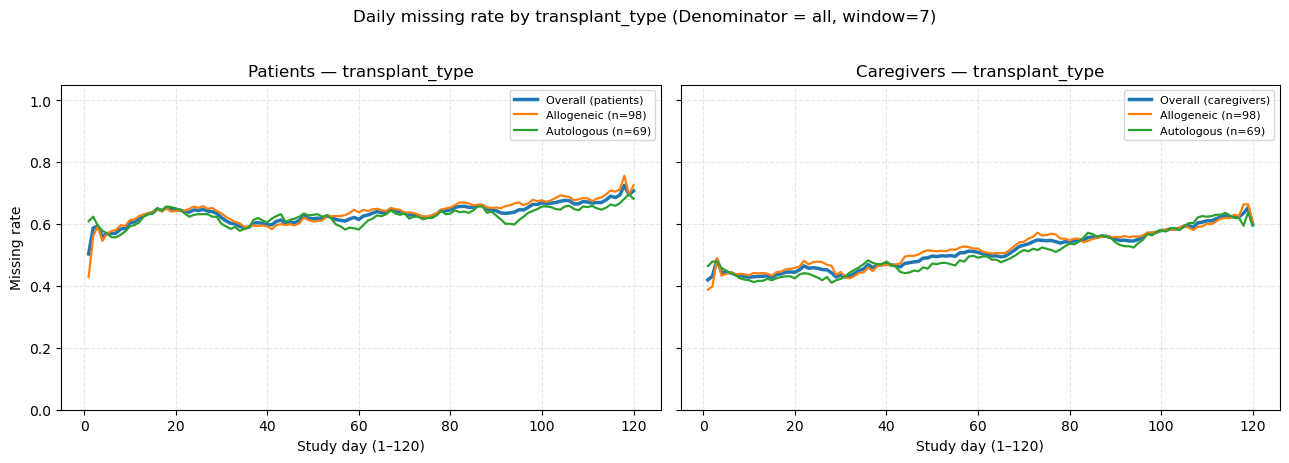

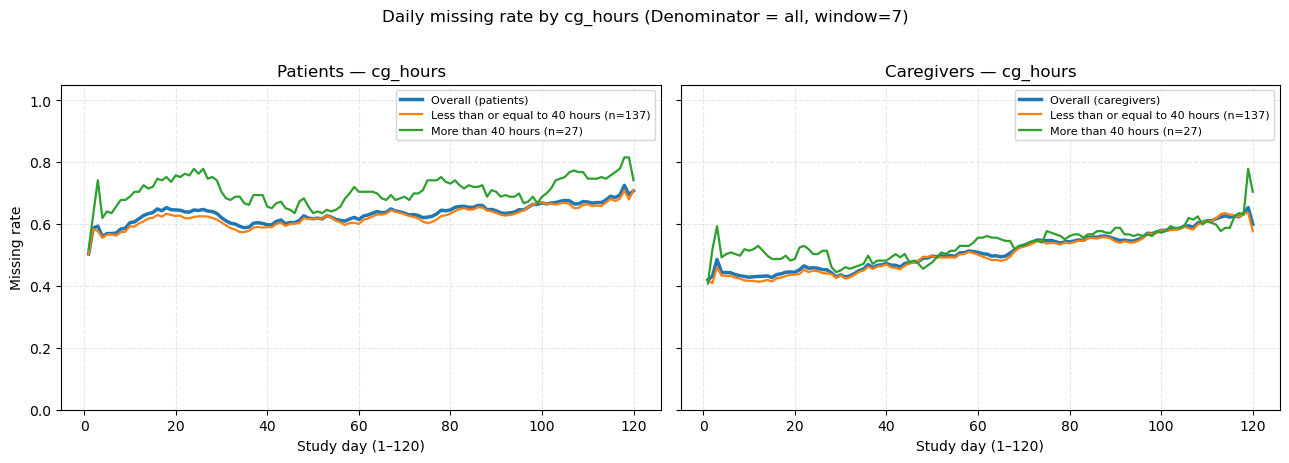

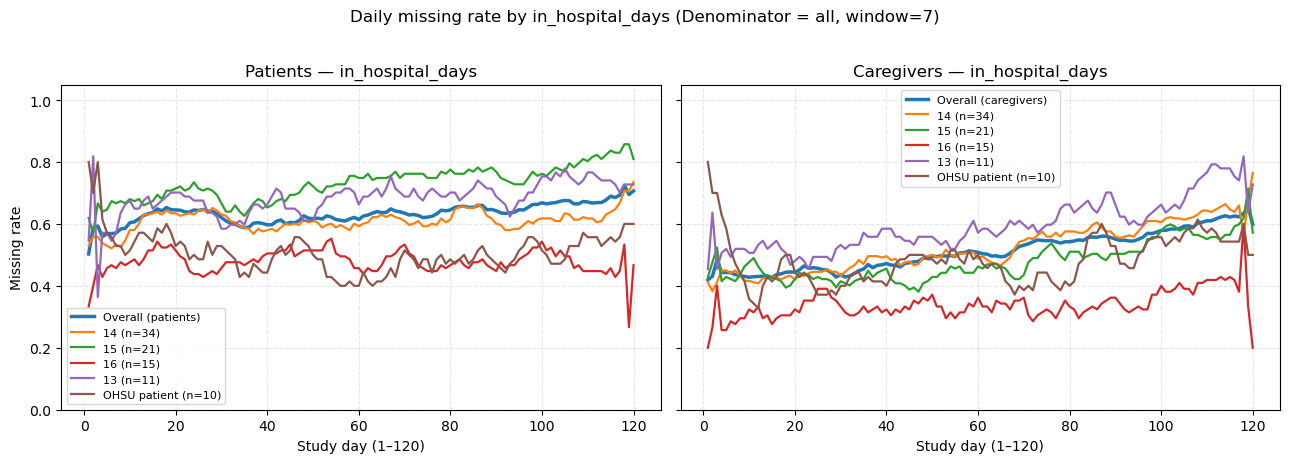

In [5]:
# %%
# Daily missing rate by role (top) and side-by-side row plots (Patients | Caregivers)
# for each other demographic field. Curves are smoothed with a centered moving average.
#
# Data source: participants_data.json
# Assumptions:
#   - node["Mood"] is a map like {"Day 4": 7.0, "Day 5": 8.0, ...} or {"4": 7.0, ...}
#   - Completion for a day = presence of a mood value on that day.
#
# Denominator strategy:
#   - "all":      all selected participants are expected each day (constant denominator = N)
#   - "enrolled": only participants who have any mood day <= current day are expected that day

import json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------
# Config
# --------------------
JSON_PATH = "participants_data.json"
MAX_DAYS  = 120
DENOMINATOR_STRATEGY = "all"   # "all" or "enrolled"
SMOOTH_WINDOW = 7              # centered moving-average window (odd number preferred)
TOP_CATS = 6                   # keep top-N categories per demographic; None => keep all
MIN_PARTICIPANTS_PER_CAT = 8   # drop categories with < this many participants
PLOT_OVERALL = True            # include overall line per panel

# Which demographic fields to compare (keys in node["Demographic"])
DEMOGRAPHIC_FIELDS = [
    "arm",
    "role",              # special: plotted alone at the very top
    "age",
    "gender",
    "monthly_income",
    "transplant_type",
    "cg_hours",
    "in_hospital_days",
]

# Figure layout
FIGSIZE_ROLE = (8, 4.5)           # size for the top role-only figure
FIGSIZE_ROW  = (13, 4.5)          # size for each row (Patients | Caregivers)
LINEWIDTH_OVERALL = 2.5
LINEWIDTH_CAT = 1.6

# --------------------
# Helpers
# --------------------
def parse_day_key(k):
    """Parse keys like 'Day 4'/'day 4'/'4' → int 4; return None if parsing fails."""
    if k is None:
        return None
    s = str(k).strip()
    if s.lower().startswith("day "):
        s = s.split(" ", 1)[1].strip()
    try:
        return int(s)
    except Exception:
        return None

def moving_average_centered(y, window=7):
    """Centered moving average with NaN padding at ends; edges fall back to raw values."""
    y = np.asarray(y, dtype=float)
    if window <= 1:
        return y
    if window % 2 == 0:
        window += 1
    half = window // 2
    out = np.full_like(y, np.nan, dtype=float)
    for i in range(half, len(y) - half):
        out[i] = np.nanmean(y[i - half:i + half + 1])
    # keep edges as original to avoid NaN shoulders
    for i in range(half):
        out[i] = y[i]
        out[-(i+1)] = y[-(i+1)]
    return out

def role_label(v):
    """Normalize role label to {'patient','caregiver'} when possible."""
    s = str(v).strip().lower()
    if s.startswith("care"):
        return "caregiver"
    if s.startswith("pat"):
        return "patient"
    return str(v)

def per_day_missing_curve(pids_subset, pid_daysets, max_days=MAX_DAYS, denominator_strategy="all"):
    """Return DataFrame day, completed_count, denominator, completion_rate, missing_rate for 1..max_days."""
    days = np.arange(1, max_days + 1, dtype=int)
    n = len(pids_subset)
    if n == 0:
        return pd.DataFrame({
            "day": days,
            "completed_count": np.zeros_like(days),
            "denominator": np.ones_like(days),  # guard
            "completion_rate": np.zeros_like(days, dtype=float),
            "missing_rate": np.ones_like(days, dtype=float),
        })

    completed_counts = np.zeros(max_days, dtype=np.int32)
    first_obs = np.full(n, np.inf, dtype=float)

    for i, pid in enumerate(pids_subset):
        dset = pid_daysets.get(pid, set())
        for d in dset:
            if 1 <= d <= max_days:
                completed_counts[d - 1] += 1
        if len(dset) > 0:
            first_obs[i] = float(min(dset))

    if denominator_strategy == "all":
        denom = np.full(max_days, n, dtype=np.int32)
    elif denominator_strategy == "enrolled":
        denom = np.zeros(max_days, dtype=np.int32)
        for idx, d in enumerate(days):
            denom[idx] = int(np.sum(first_obs <= d))
        denom = np.where(denom == 0, 1, denom)
    else:
        raise ValueError("denominator_strategy must be 'all' or 'enrolled'.")

    completion_rate = completed_counts / denom
    missing_rate = 1.0 - completion_rate

    return pd.DataFrame({
        "day": days,
        "completed_count": completed_counts,
        "denominator": denom,
        "completion_rate": completion_rate,
        "missing_rate": missing_rate
    })

def select_categories_for_field(field, pids, pid_demo, top_cats=TOP_CATS, min_n=MIN_PARTICIPANTS_PER_CAT):
    """Return (categories, counts) for a demographic field, thresholded and truncated."""
    vals = []
    for pid in pids:
        v = pid_demo.get(pid, {}).get(field, None)
        if v is not None and v != "":
            vals.append(v)
    cnt = Counter(vals)
    kept = [(cat, c) for cat, c in cnt.items() if c >= min_n]
    kept.sort(key=lambda x: x[1], reverse=True)
    if top_cats is not None:
        kept = kept[:top_cats]
    return [cat for cat, _ in kept], cnt

# --------------------
# Load JSON
# --------------------
json_path = Path(JSON_PATH)
if not json_path.exists():
    raise FileNotFoundError(f"JSON not found at: {json_path.resolve()}")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# --------------------
# Pre-collect pid -> demographics, pid -> completed day set
# --------------------
pid_demo = {}
pid_daysets = {}
all_pids = []

for pid, node in data.items():
    if not isinstance(node, dict):
        continue
    demo = node.get("Demographic", {}) or {}
    mood_map = node.get("Mood", {}) or {}

    day_set = set()
    for k in mood_map.keys():
        d = parse_day_key(k)
        if d is not None and 1 <= d <= MAX_DAYS:
            day_set.add(d)

    pid_demo[pid] = demo
    pid_daysets[pid] = day_set
    all_pids.append(pid)

all_pids = [p for p in all_pids if isinstance(pid_daysets.get(p), set)]
patients = [pid for pid in all_pids if role_label(pid_demo.get(pid, {}).get("role", "")) == "patient"]
caregivers = [pid for pid in all_pids if role_label(pid_demo.get(pid, {}).get("role", "")) == "caregiver"]

print(f"[INFO] Total participants: {len(all_pids)}  |  Patients: {len(patients)}  |  Caregivers: {len(caregivers)}")

# --------------------
# Top figure: daily missing rate by role (unconditioned)
# --------------------
# Build role curves
role_cats = []
for raw_role in ["patient", "caregiver"]:
    # include only if present
    if (raw_role == "patient" and len(patients) > 0) or (raw_role == "caregiver" and len(caregivers) > 0):
        role_cats.append(raw_role)

role_curves = {}
role_sizes = {}
for cat in role_cats:
    pids_cat = patients if cat == "patient" else caregivers
    role_sizes[cat] = len(pids_cat)
    role_curves[cat] = per_day_missing_curve(pids_cat, pid_daysets, MAX_DAYS, DENOMINATOR_STRATEGY)

overall_all = per_day_missing_curve(all_pids, pid_daysets, MAX_DAYS, DENOMINATOR_STRATEGY) if PLOT_OVERALL else None

plt.figure(figsize=FIGSIZE_ROLE)
if PLOT_OVERALL and overall_all is not None:
    y = overall_all["missing_rate"].to_numpy(float)
    y_s = moving_average_centered(y, SMOOTH_WINDOW)
    plt.plot(overall_all["day"], y_s, label="Overall (smoothed)", linewidth=LINEWIDTH_OVERALL)

for cat in role_cats:
    dfc = role_curves[cat]
    y = dfc["missing_rate"].to_numpy(float)
    y_s = moving_average_centered(y, SMOOTH_WINDOW)
    label = f"{cat.capitalize()} (n={role_sizes[cat]})"
    plt.plot(dfc["day"], y_s, label=label, linewidth=LINEWIDTH_CAT)

plt.xlabel("Study day (1–120)")
plt.ylabel("Missing rate")
plt.title(f"Daily missing rate by role (Denominator = {DENOMINATOR_STRATEGY}, window={SMOOTH_WINDOW})")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

# --------------------
# For each other demographic: Patients (left) | Caregivers (right) on one row
# --------------------
for field in [f for f in DEMOGRAPHIC_FIELDS if f != "role"]:
    # Prepare category lists conditioned on role
    # Patients
    pids_subset_pat = patients
    cats_pat, _ = select_categories_for_field(field, pids_subset_pat, pid_demo,
                                              top_cats=TOP_CATS, min_n=MIN_PARTICIPANTS_PER_CAT)
    # Caregivers
    pids_subset_cg  = caregivers
    cats_cg, _ = select_categories_for_field(field, pids_subset_cg, pid_demo,
                                             top_cats=TOP_CATS, min_n=MIN_PARTICIPANTS_PER_CAT)

    if not cats_pat and not cats_cg:
        print(f"[WARN] Skip '{field}' (no categories passing thresholds in either role).")
        continue

    fig, axes = plt.subplots(ncols=2, figsize=FIGSIZE_ROW, sharey=True)
    ax_pat, ax_cg = axes

    # --- Patients panel (left) ---
    if cats_pat:
        curves = {}
        sizes  = {}
        for cat in cats_pat:
            pids_cat = [pid for pid in pids_subset_pat if pid_demo.get(pid, {}).get(field, None) == cat]
            sizes[cat] = len(pids_cat)
            curves[cat] = per_day_missing_curve(pids_cat, pid_daysets, MAX_DAYS, DENOMINATOR_STRATEGY)

        overall_pat = per_day_missing_curve(pids_subset_pat, pid_daysets, MAX_DAYS, DENOMINATOR_STRATEGY) if PLOT_OVERALL else None

        if PLOT_OVERALL and overall_pat is not None:
            y = overall_pat["missing_rate"].to_numpy(float)
            y_s = moving_average_centered(y, SMOOTH_WINDOW)
            ax_pat.plot(overall_pat["day"], y_s, label="Overall (patients)", linewidth=LINEWIDTH_OVERALL)

        for cat in cats_pat:
            dfc = curves[cat]
            y = dfc["missing_rate"].to_numpy(float)
            y_s = moving_average_centered(y, SMOOTH_WINDOW)
            ax_pat.plot(dfc["day"], y_s, label=f"{cat} (n={sizes[cat]})", linewidth=LINEWIDTH_CAT)

        ax_pat.set_title(f"Patients — {field}")
        ax_pat.set_xlabel("Study day (1–120)")
        ax_pat.set_ylabel("Missing rate")
        ax_pat.set_ylim(0, 1.05)
        ax_pat.grid(True, linestyle="--", alpha=0.3)
        ax_pat.legend(loc="best", fontsize=8)
    else:
        ax_pat.axis("off")
        ax_pat.set_title(f"Patients — {field} (no categories)")

    # --- Caregivers panel (right) ---
    if cats_cg:
        curves = {}
        sizes  = {}
        for cat in cats_cg:
            pids_cat = [pid for pid in pids_subset_cg if pid_demo.get(pid, {}).get(field, None) == cat]
            sizes[cat] = len(pids_cat)
            curves[cat] = per_day_missing_curve(pids_cat, pid_daysets, MAX_DAYS, DENOMINATOR_STRATEGY)

        overall_cg = per_day_missing_curve(pids_subset_cg, pid_daysets, MAX_DAYS, DENOMINATOR_STRATEGY) if PLOT_OVERALL else None

        if PLOT_OVERALL and overall_cg is not None:
            y = overall_cg["missing_rate"].to_numpy(float)
            y_s = moving_average_centered(y, SMOOTH_WINDOW)
            ax_cg.plot(overall_cg["day"], y_s, label="Overall (caregivers)", linewidth=LINEWIDTH_OVERALL)

        for cat in cats_cg:
            dfc = curves[cat]
            y = dfc["missing_rate"].to_numpy(float)
            y_s = moving_average_centered(y, SMOOTH_WINDOW)
            ax_cg.plot(dfc["day"], y_s, label=f"{cat} (n={sizes[cat]})", linewidth=LINEWIDTH_CAT)

        ax_cg.set_title(f"Caregivers — {field}")
        ax_cg.set_xlabel("Study day (1–120)")
        ax_cg.set_ylim(0, 1.05)
        ax_cg.grid(True, linestyle="--", alpha=0.3)
        ax_cg.legend(loc="best", fontsize=8)
    else:
        ax_cg.axis("off")
        ax_cg.set_title(f"Caregivers — {field} (no categories)")

    fig.suptitle(f"Daily missing rate by {field} (Denominator = {DENOMINATOR_STRATEGY}, window={SMOOTH_WINDOW})",
                 y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()


[OK] Conditional probabilities computed for k=1..9


,k,denominator,numerator,prob_not_complete_next
0,1,22482,18214,0.810159
1,2,17810,16024,0.899719
2,3,15775,14740,0.934390
3,4,14565,13893,0.953862
4,5,13695,13186,0.962833
5,6,13045,12644,0.969260
6,7,12497,12159,0.972954
7,8,12027,11728,0.975139
8,9,11607,11338,0.976824


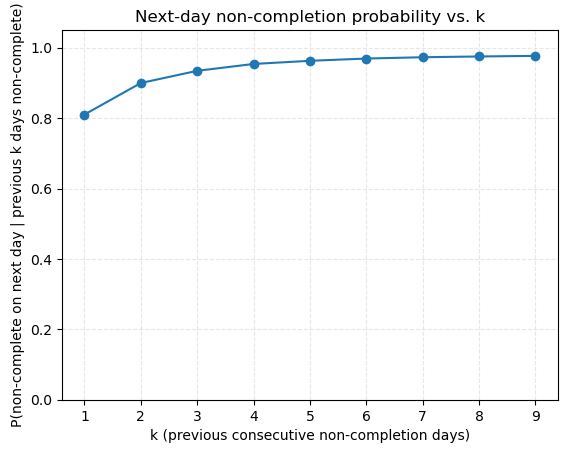

In [6]:
# %%
# Compute conditional probabilities:
#   For k in {1..9}, P(not complete on day t+1 | previous k days all not complete)
# Data source: participants_data.json
#
# Assumptions:
#   - node["Mood"] is a flat mapping: { "Day N" or "N" : <mood float> }
#   - Completion for a day = presence of a mood value for that day
#   - By default, we evaluate on fixed study days 1..120 for every participant (can switch to per-participant range)

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

JSON_PATH = "participants_data.json"

# --- Window settings ---
USE_FIXED_WINDOW = True   # True: use days 1..MAX_DAYS for all participants; False: per-participant min..max
MAX_DAYS = 120            # only used when USE_FIXED_WINDOW = True
START_DAY = 1             # lower bound for fixed window

# --------------------
# Load JSON
# --------------------
json_path = Path(JSON_PATH)
if not json_path.exists():
    raise FileNotFoundError(f"JSON not found at: {json_path.resolve()}")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# --------------------
# Utilities
# --------------------
def parse_day_key(k):
    """
    Parse keys like 'Day 4'/'day 4'/'4' -> int 4.
    Return None if parsing fails.
    """
    if k is None:
        return None
    s = str(k).strip()
    if s.lower().startswith("day "):
        s = s.split(" ", 1)[1].strip()
    try:
        return int(s)
    except Exception:
        return None

# --------------------
# Helper to build a completion vector for a participant
# --------------------
def build_completion_array(mood_map: dict, use_fixed_window: bool, max_days: int, start_day: int = 1):
    """
    Return (days_array, comp_array) where comp_array[i] = 1 if completed on day=days_array[i], else 0.
    """
    # Normalize mood days to ints
    days_completed = set()
    for k in mood_map.keys():
        d = parse_day_key(k)
        if d is not None:
            days_completed.add(d)

    if use_fixed_window:
        days = np.arange(start_day, max_days + 1, dtype=int)
    else:
        if len(days_completed) == 0:
            return np.array([], dtype=int), np.array([], dtype=int)
        dmin, dmax = min(days_completed), max(days_completed)
        days = np.arange(dmin, dmax + 1, dtype=int)

    comp = np.array([1 if d in days_completed else 0 for d in days], dtype=int)
    return days, comp

# --------------------
# Core counting for k=1..9
# --------------------
results = []
for k in range(1, 10):
    denom = 0  # count of occasions where previous k days all not complete
    numer = 0  # among those, count of next day also not complete

    for pid, node in data.items():
        if not isinstance(node, dict):
            continue
        mood_map = node.get("Mood", {}) or {}
        days, comp = build_completion_array(mood_map, USE_FIXED_WINDOW, MAX_DAYS, START_DAY)
        if len(days) == 0:
            continue

        # indices i from k to len(days)-2:
        #   previous k days: comp[i-k : i]
        #   next day: comp[i+1]
        for i in range(k, len(days) - 1):
            prev_k = comp[i - k:i]
            if prev_k.sum() == 0:  # all previous k days not complete
                denom += 1
                if comp[i + 1] == 0:
                    numer += 1

    prob = (numer / denom) if denom > 0 else np.nan
    results.append({
        "k": k,
        "denominator": denom,
        "numerator": numer,
        "prob_not_complete_next": prob
    })

prob_df = pd.DataFrame(results)
print("[OK] Conditional probabilities computed for k=1..9")
display(prob_df)

# --------------------
# Plot
# --------------------
plt.figure()
plt.plot(prob_df["k"], prob_df["prob_not_complete_next"], marker="o")
plt.xticks(range(1, 10))
plt.xlabel("k (previous consecutive non-completion days)")
plt.ylabel("P(non-complete on next day | previous k days non-complete)")
plt.title("Next-day non-completion probability vs. k")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


[INFO] Total participants found: 334
[INFO] Patients: 167 | Caregivers: 167


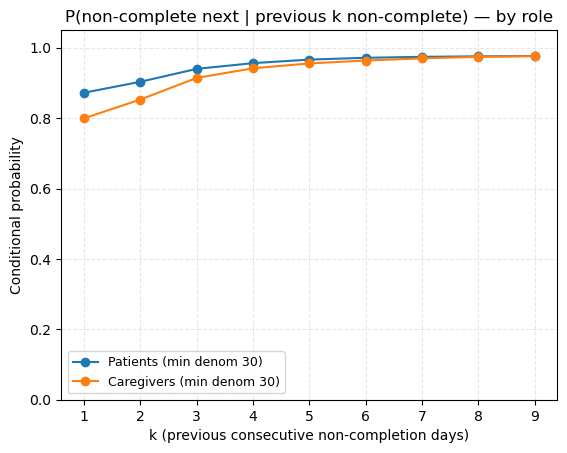

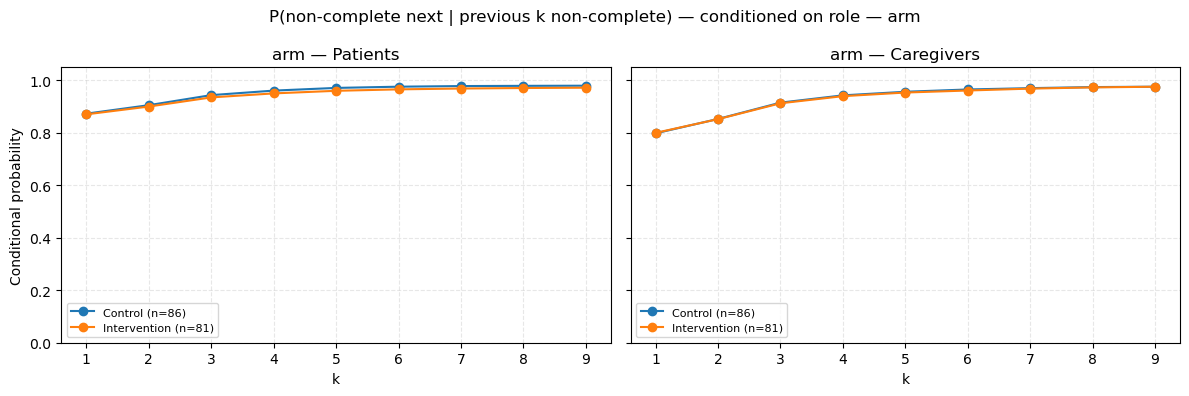

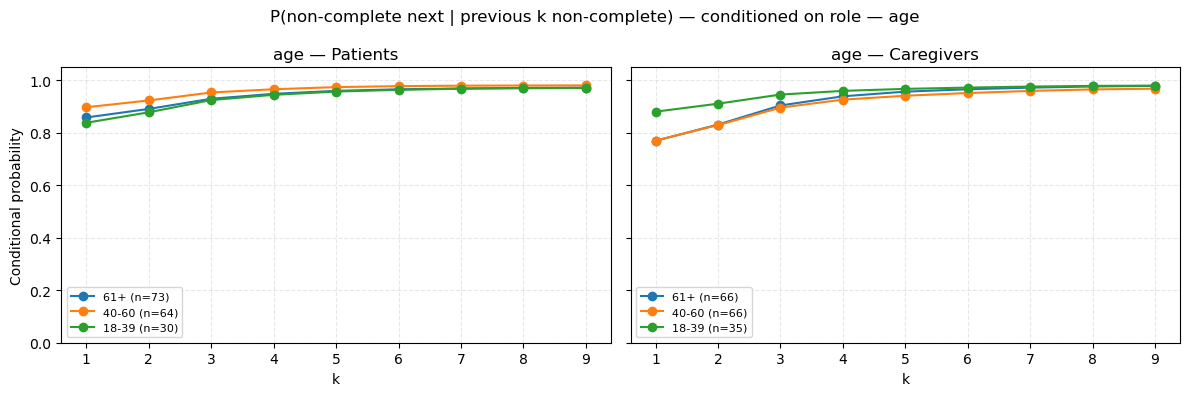

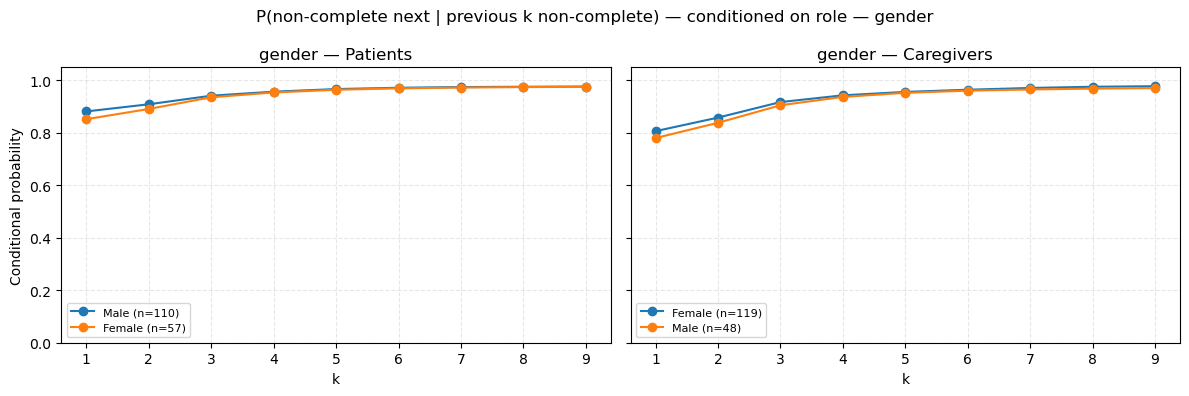

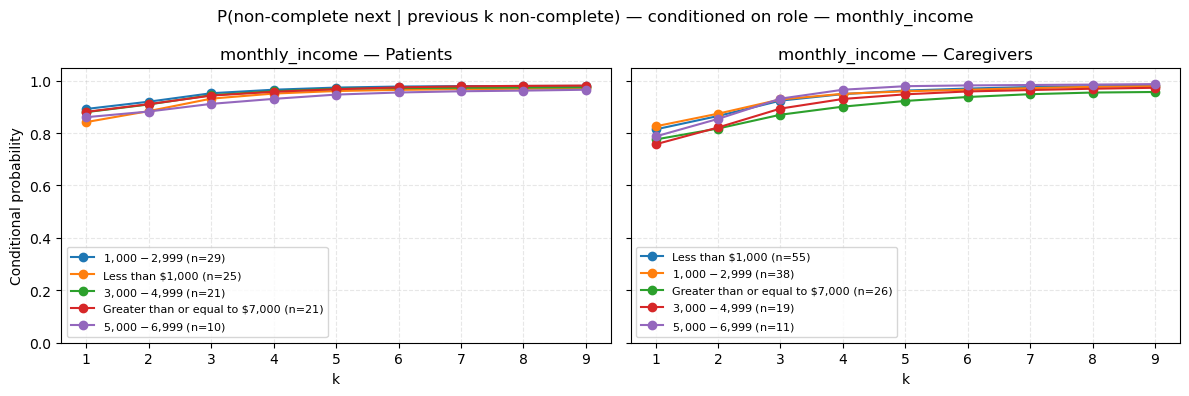

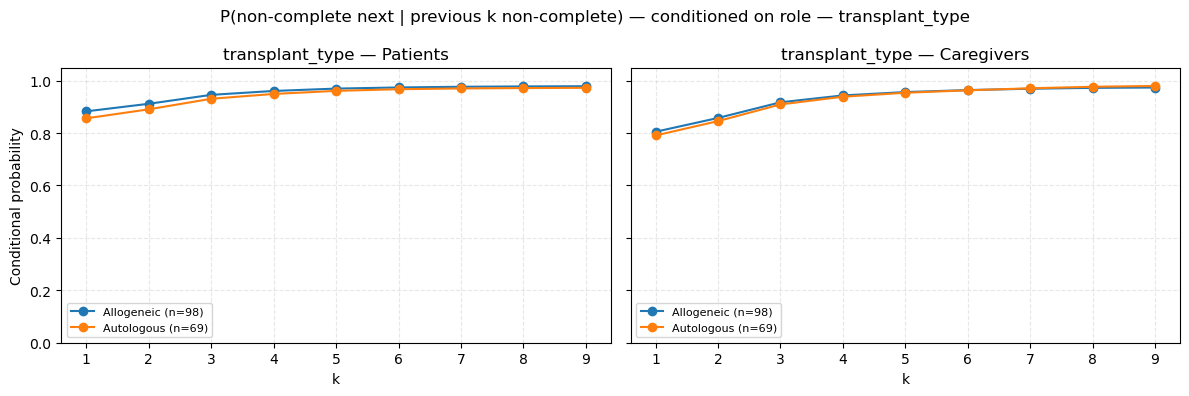

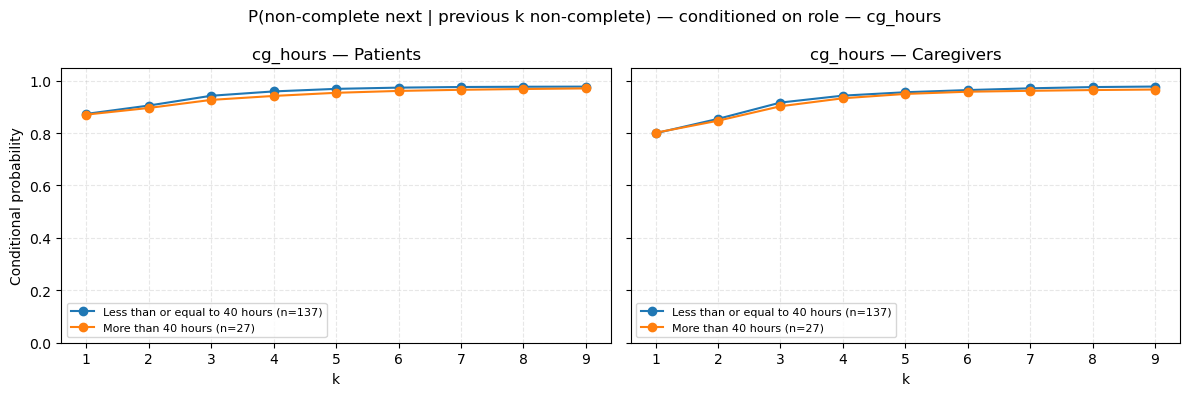

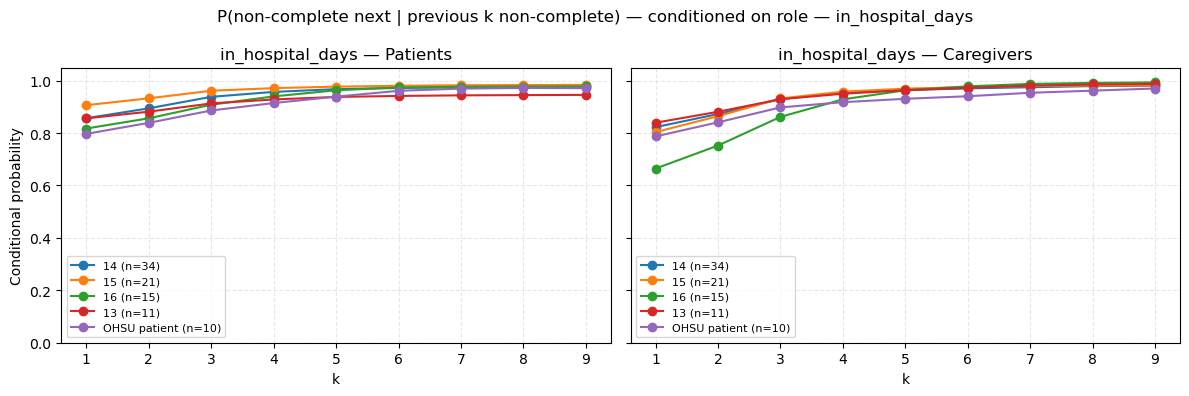

[OK] Built tidy table for all plotted lines.


,demo_field,role,demo_value,k,numerator,denominator,prob,n_participants
0,role,Patients,Patients,1,10568,12448,0.848972,167
1,role,Patients,Patients,2,9516,10362,0.918356,167
2,role,Patients,Patients,3,8850,9391,0.942392,167
3,role,Patients,Patients,4,8411,8771,0.958956,167
4,role,Patients,Patients,5,8027,8299,0.967225,167
5,role,Patients,Patients,6,7731,7948,0.972698,167
6,role,Patients,Patients,7,7456,7653,0.974258,167
7,role,Patients,Patients,8,7213,7394,0.975521,167
8,role,Patients,Patients,9,6989,7155,0.976799,167
9,role,Caregivers,Caregivers,1,7646,10034,0.762009,167


In [7]:
# %%
# Compare P(non-complete on day t+1 | previous k days all non-complete) across demographics,
# with conditioning on role:
#   - First, plot role-only figure (patients vs caregivers) at the top.
#   - Then, for each other demographic, plot two panels in one row: Patients (left) | Caregivers (right),
#     each panel shows multiple category lines within that role.
#
# Data source: participants_data.json
#
# Notes:
#   - Completion on a day = presence of a mood value for that day.
#   - Fixed window days 1..MAX_DAYS by default (switchable).
#   - Curves are lightly smoothed with a moving average over k (window=3).
#   - Points with denominator < MIN_DENOM_PER_POINT are masked (not plotted).
#
# Dependencies: numpy, pandas, matplotlib

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from typing import Dict, Tuple, List

JSON_PATH = "participants_data.json"

# ----- Window settings -----
USE_FIXED_WINDOW = True     # True: use days 1..MAX_DAYS for everyone; False: per-participant min..max
MAX_DAYS = 120
START_DAY = 1               # lower bound for fixed window

# ----- Demographic fields to compare (must exist under node["Demographic"]) -----
DEMOGRAPHIC_FIELDS = [
    "arm",
    "role",               # special handling: gets its own top figure
    "age",
    "gender",
    "monthly_income",
    "transplant_type",
    "cg_hours",
    "in_hospital_days",
]

# ----- Category selection & plotting thresholds -----
TOP_CATS = 6                    # per demographic per role, keep top-N categories by participant count (None = all)
MIN_PARTICIPANTS_PER_CAT = 10   # drop categories with < this many participants (evaluated within each role)
MIN_DENOM_PER_POINT = 30        # hide a (k, category) point if its denominator < threshold

# ----- Smoothing settings (over k) -----
SMOOTH_WINDOW = 3               # moving-average window over k; set to 1 to disable smoothing
SMOOTH_CENTERED = True          # centered window if possible

# --------------------
# Load data
# --------------------
json_path = Path(JSON_PATH)
if not json_path.exists():
    raise FileNotFoundError(f"JSON not found at: {json_path.resolve()}")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# --------------------
# Utilities
# --------------------
def parse_day_key(k) -> int | None:
    """
    Parse keys like 'Day 4'/'day 4'/'4' -> int 4.
    Return None if parsing fails.
    """
    if k is None:
        return None
    s = str(k).strip()
    if s.lower().startswith("day "):
        s = s.split(" ", 1)[1].strip()
    try:
        return int(s)
    except Exception:
        return None

def build_completion_array(mood_map: dict,
                           use_fixed_window: bool,
                           max_days: int,
                           start_day: int = 1) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return (days_array, comp_array) where comp[i] = 1 if completed on day=days_array[i], else 0.
    """
    completed = set()
    for k in mood_map.keys():
        d = parse_day_key(k)
        if d is not None:
            completed.add(d)

    if use_fixed_window:
        days = np.arange(start_day, max_days + 1, dtype=int)
    else:
        if not completed:
            return np.array([], dtype=int), np.array([], dtype=int)
        days = np.arange(min(completed), max(completed) + 1, dtype=int)

    comp = np.array([1 if d in completed else 0 for d in days], dtype=int)
    return days, comp

def moving_average(y: np.ndarray, window: int, centered: bool = True) -> np.ndarray:
    """
    Simple moving average with NaN-aware masking.
    If window <= 1, returns y unchanged.
    """
    if window is None or window <= 1:
        return y
    y = y.astype(float)
    mask = ~np.isnan(y)
    y_filled = np.where(mask, y, 0.0)

    if centered:
        pad = window // 2
        y_pad = np.pad(y_filled, (pad, pad), mode='edge')
        m_pad = np.pad(mask.astype(float), (pad, pad), mode='edge')
        num = np.convolve(y_pad, np.ones(window, dtype=float), mode='valid')
        den = np.convolve(m_pad, np.ones(window, dtype=float), mode='valid')
    else:
        num = np.convolve(y_filled, np.ones(window, dtype=float), mode='same')
        den = np.convolve(mask.astype(float), np.ones(window, dtype=float), mode='same')

    out = num / np.where(den == 0, np.nan, den)
    return out

# --------------------
# Collect per-pid demographics and completion vectors
# --------------------
pid_demo: Dict[str, Dict] = {}
pid_comp: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}   # pid -> (days, comp)
all_pids: List[str] = []

for pid, node in data.items():
    if not isinstance(node, dict):
        continue
    demo = node.get("Demographic", {}) or {}
    mood_map = node.get("Mood", {}) or {}

    pid_demo[pid] = demo
    days, comp = build_completion_array(mood_map, USE_FIXED_WINDOW, MAX_DAYS, START_DAY)
    pid_comp[pid] = (days, comp)
    all_pids.append(pid)

all_pids = [p for p in all_pids if isinstance(pid_comp.get(p), tuple)]
print(f"[INFO] Total participants found: {len(all_pids)}")

# Helper to split by role quickly
def pids_by_role(role_name: str) -> List[str]:
    return [pid for pid in all_pids if pid_demo.get(pid, {}).get("role") == role_name]

P_PATIENTS = pids_by_role("Patients")
P_CAREGIVERS = pids_by_role("Caregivers")
print(f"[INFO] Patients: {len(P_PATIENTS)} | Caregivers: {len(P_CAREGIVERS)}")

# --------------------
# Core metric function
# --------------------
def conditional_line_for_pid_set(pids, k_values=range(1, 10)) -> pd.DataFrame:
    """
    For the given pid set, compute for each k:
      P(non-complete on day i+1 | comp[i-k:i] are all zeros).
    Returns DataFrame: k, numerator, denominator, prob
    """
    out = []
    for k in k_values:
        denom = 0
        numer = 0
        for pid in pids:
            days, comp = pid_comp.get(pid, (None, None))
            if days is None or comp is None or len(days) == 0:
                continue
            # indices i where previous k days exist and next day exists
            for i in range(k, len(days) - 1):
                prev_k = comp[i - k:i]
                if prev_k.sum() == 0:
                    denom += 1
                    if comp[i + 1] == 0:
                        numer += 1
        prob = (numer / denom) if denom > 0 else np.nan
        out.append({"k": k, "numerator": numer, "denominator": denom, "prob": prob})
    return pd.DataFrame(out)

# --------------------
# Category selection per demographic *within a role*
# --------------------
def select_categories_within_role(field: str, role_name: str) -> List[str]:
    vals = []
    for pid in all_pids:
        demo = pid_demo.get(pid, {})
        if demo.get("role") != role_name:
            continue
        v = demo.get(field, None)
        if v is not None and v != "":
            vals.append(v)
    ctr = Counter(vals)
    # filter by min participants (within this role)
    items = [(cat, n) for cat, n in ctr.items() if n >= MIN_PARTICIPANTS_PER_CAT]
    items.sort(key=lambda x: x[1], reverse=True)
    if TOP_CATS is not None:
        items = items[:TOP_CATS]
    return [cat for cat, _ in items]

# --------------------
# ROLE-ONLY figure at the top
# --------------------
role_lines = []
role_lines.append(("Patients", conditional_line_for_pid_set(P_PATIENTS)))
role_lines.append(("Caregivers", conditional_line_for_pid_set(P_CAREGIVERS)))

plt.figure()
for role_name, df in role_lines:
    df = df.sort_values("k").copy()
    # mask by denominator
    mask = df["denominator"] >= MIN_DENOM_PER_POINT
    ks = df.loc[mask, "k"].to_numpy()
    ps = df.loc[mask, "prob"].to_numpy()
    # smooth
    ps_sm = moving_average(ps, SMOOTH_WINDOW, SMOOTH_CENTERED)
    plt.plot(ks, ps_sm, marker="o", label=f"{role_name} (min denom {MIN_DENOM_PER_POINT})")
plt.title("P(non-complete next | previous k non-complete) — by role")
plt.xlabel("k (previous consecutive non-completion days)")
plt.ylabel("Conditional probability")
plt.xticks(range(1, 10))
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="best", fontsize=9)
plt.show()

# --------------------
# For each demographic (except 'role'): one row with two panels (Patients | Caregivers)
# --------------------
for field in DEMOGRAPHIC_FIELDS:
    if field == "role":
        continue  # role already plotted above

    # Select categories separately within each role
    cats_pat = select_categories_within_role(field, "Patients")
    cats_cg  = select_categories_within_role(field, "Caregivers")

    # If no categories pass thresholds in both roles, skip
    if not cats_pat and not cats_cg:
        print(f"[WARN] Skip '{field}' (no categories passing thresholds in either role).")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    ax_pat, ax_cg = axes

    # --- Left: Patients ---
    if cats_pat:
        for cat in cats_pat:
            pids_cat = [pid for pid in P_PATIENTS if pid_demo.get(pid, {}).get(field) == cat]
            df = conditional_line_for_pid_set(pids_cat).sort_values("k")
            mask = df["denominator"] >= MIN_DENOM_PER_POINT
            ks = df.loc[mask, "k"].to_numpy()
            ps = df.loc[mask, "prob"].to_numpy()
            if ks.size == 0:
                continue
            ps_sm = moving_average(ps, SMOOTH_WINDOW, SMOOTH_CENTERED)
            ax_pat.plot(ks, ps_sm, marker="o", label=f"{cat} (n={len(pids_cat)})")
    ax_pat.set_title(f"{field} — Patients")
    ax_pat.set_xlabel("k")
    ax_pat.set_ylabel("Conditional probability")
    ax_pat.set_xticks(range(1, 10))
    ax_pat.set_ylim(0, 1.05)
    ax_pat.grid(True, linestyle="--", alpha=0.3)
    if cats_pat:
        ax_pat.legend(loc="best", fontsize=8)

    # --- Right: Caregivers ---
    if cats_cg:
        for cat in cats_cg:
            pids_cat = [pid for pid in P_CAREGIVERS if pid_demo.get(pid, {}).get(field) == cat]
            df = conditional_line_for_pid_set(pids_cat).sort_values("k")
            mask = df["denominator"] >= MIN_DENOM_PER_POINT
            ks = df.loc[mask, "k"].to_numpy()
            ps = df.loc[mask, "prob"].to_numpy()
            if ks.size == 0:
                continue
            ps_sm = moving_average(ps, SMOOTH_WINDOW, SMOOTH_CENTERED)
            axes[1].plot(ks, ps_sm, marker="o", label=f"{cat} (n={len(pids_cat)})")
    ax_cg.set_title(f"{field} — Caregivers")
    ax_cg.set_xlabel("k")
    ax_cg.set_xticks(range(1, 10))
    ax_cg.set_ylim(0, 1.05)
    ax_cg.grid(True, linestyle="--", alpha=0.3)
    if cats_cg:
        ax_cg.legend(loc="best", fontsize=8)

    fig.suptitle(f"P(non-complete next | previous k non-complete) — conditioned on role — {field}")
    fig.tight_layout()
    plt.show()

# --------------------
# (Optional) Export a tidy table for downstream analysis
# --------------------
# Build a long DataFrame for all plotted lines (use the same thresholds)
rows = []

def append_rows_for(field_name: str, role_name: str, cats: List[str], base_pids: List[str]):
    for cat in cats:
        pids_cat = [pid for pid in base_pids if pid_demo.get(pid, {}).get(field_name) == cat]
        df = conditional_line_for_pid_set(pids_cat)
        for _, r in df.iterrows():
            rows.append({
                "demo_field": field_name,
                "role": role_name,
                "demo_value": cat,
                "k": int(r["k"]),
                "numerator": int(r["numerator"]),
                "denominator": int(r["denominator"]),
                "prob": float(r["prob"]) if pd.notna(r["prob"]) else np.nan,
                "n_participants": len(pids_cat),
            })

# role-only rows
df_pat_role = conditional_line_for_pid_set(P_PATIENTS)
for _, r in df_pat_role.iterrows():
    rows.append({
        "demo_field": "role",
        "role": "Patients",
        "demo_value": "Patients",
        "k": int(r["k"]),
        "numerator": int(r["numerator"]),
        "denominator": int(r["denominator"]),
        "prob": float(r["prob"]) if pd.notna(r["prob"]) else np.nan,
        "n_participants": len(P_PATIENTS),
    })
df_cg_role = conditional_line_for_pid_set(P_CAREGIVERS)
for _, r in df_cg_role.iterrows():
    rows.append({
        "demo_field": "role",
        "role": "Caregivers",
        "demo_value": "Caregivers",
        "k": int(r["k"]),
        "numerator": int(r["numerator"]),
        "denominator": int(r["denominator"]),
        "prob": float(r["prob"]) if pd.notna(r["prob"]) else np.nan,
        "n_participants": len(P_CAREGIVERS),
    })

# per-demographic, conditioned on role
for field in DEMOGRAPHIC_FIELDS:
    if field == "role":
        continue
    cats_pat = select_categories_within_role(field, "Patients")
    cats_cg  = select_categories_within_role(field, "Caregivers")
    if cats_pat:
        append_rows_for(field, "Patients", cats_pat, P_PATIENTS)
    if cats_cg:
        append_rows_for(field, "Caregivers", cats_cg, P_CAREGIVERS)

results_df = pd.DataFrame(rows)
print("[OK] Built tidy table for all plotted lines.")
display(results_df.head(12))


[OK] Conditional probabilities P(complete at t+1 | mood_t = m)


,mood_bin,numerator,denominator,prob_complete_next
0,1,170,250,0.680000
1,2,116,167,0.694611
2,3,236,308,0.766234
3,4,403,554,0.727437
4,5,658,910,0.723077
5,6,1326,1858,0.713671
6,7,2216,3001,0.738421
7,8,3716,5001,0.743051
8,9,2222,3092,0.718629
9,10,1405,1898,0.740253


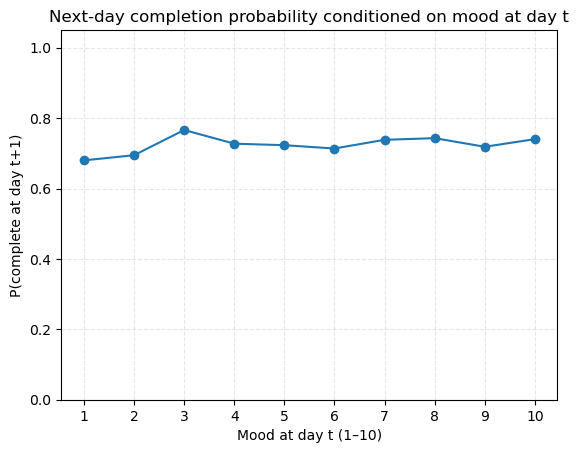

In [8]:
# %%
# P(complete on day t+1 | mood on day t = m), m=1..10
# Data source: participants_data.json
# Definition:
#   - "Complete on day t+1" := there exists a mood value recorded on day (t+1)
#   - Mood binning: round (or floor/ceil) to an integer in [1,10]
# Analysis window: days 1..MAX_DAYS (we only count t where t+1 is also within the window)

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

JSON_PATH = "participants_data.json"
MAX_DAYS  = 120   # set to None to use all available days; else restrict to 1..MAX_DAYS
ROUNDING_METHOD = "round"  # "round" | "floor" | "ceil"

# --------------------
# Load JSON
# --------------------
json_path = Path(JSON_PATH)
if not json_path.exists():
    raise FileNotFoundError(f"JSON not found at: {json_path.resolve()}")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# --------------------
# Helpers
# --------------------
def parse_day_key(k):
    """
    Parse keys like 'Day 4' / 'day 4' / '4' -> int 4. Return None if parsing fails.
    """
    if k is None:
        return None
    s = str(k).strip()
    if s.lower().startswith("day "):
        s = s.split(" ", 1)[1].strip()
    try:
        return int(s)
    except Exception:
        return None

def mood_to_bin(x, method="round"):
    """
    Map a numeric mood to an integer bin in [1,10] using the specified rounding method.
    Returns None if x is not parseable as a float.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    try:
        xv = float(x)
    except Exception:
        return None

    if method == "floor":
        m = int(np.floor(xv))
    elif method == "ceil":
        m = int(np.ceil(xv))
    else:  # "round"
        m = int(np.rint(xv))
    return max(1, min(10, m))

# --------------------
# Count numerators / denominators per mood bin
# --------------------
moods = list(range(1, 11))
numer = {m: 0 for m in moods}   # count of (t+1 completed) given mood_t = m
denom = {m: 0 for m in moods}   # count of valid trials with mood_t = m (and t+1 within window)

# Precompute upper bound for t so that t+1 is inside the analysis window (if capped)
if MAX_DAYS is None:
    t_upper_limit = None
else:
    t_upper_limit = MAX_DAYS - 1  # last valid t so that t+1 <= MAX_DAYS

for pid, node in data.items():
    if not isinstance(node, dict):
        continue
    mood_map = node.get("Mood", {}) or {}

    # Normalize day keys to int and (optionally) keep within window
    day_to_mood = {}
    for k, v in mood_map.items():
        d = parse_day_key(k)
        if d is None:
            continue
        if MAX_DAYS is not None and not (1 <= d <= MAX_DAYS):
            continue
        day_to_mood[d] = v

    if not day_to_mood:
        continue

    days_sorted = sorted(day_to_mood.keys())

    # Iterate t where t+1 is within analysis window
    for t in days_sorted:
        if t_upper_limit is not None and t > t_upper_limit:
            continue  # cannot evaluate t+1 inside the window

        m_bin = mood_to_bin(day_to_mood.get(t, None), method=ROUNDING_METHOD)
        if m_bin is None:
            continue

        # Denominator: every observed mood at day t (with valid t+1 in window)
        denom[m_bin] += 1

        # Numerator: completion at t+1 means (t+1) exists in day_to_mood
        if (t + 1) in day_to_mood:
            numer[m_bin] += 1

# --------------------
# Build result table
# --------------------
rows = []
for m in moods:
    d = denom[m]
    n = numer[m]
    p = (n / d) if d > 0 else np.nan
    rows.append({
        "mood_bin": m,
        "numerator": n,
        "denominator": d,
        "prob_complete_next": p
    })

result = pd.DataFrame(rows)
print("[OK] Conditional probabilities P(complete at t+1 | mood_t = m)")
try:
    display(result)
except Exception:
    print(result)

# --------------------
# Plot
# --------------------
plt.figure()
plt.plot(result["mood_bin"], result["prob_complete_next"], marker="o")
plt.xticks(moods)
plt.xlabel("Mood at day t (1–10)")
plt.ylabel("P(complete at day t+1)")
plt.title("Next-day completion probability conditioned on mood at day t")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


[INFO] Participants loaded: 334


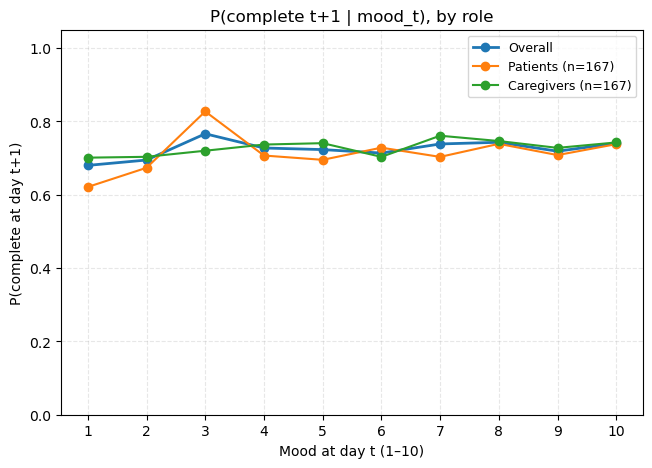

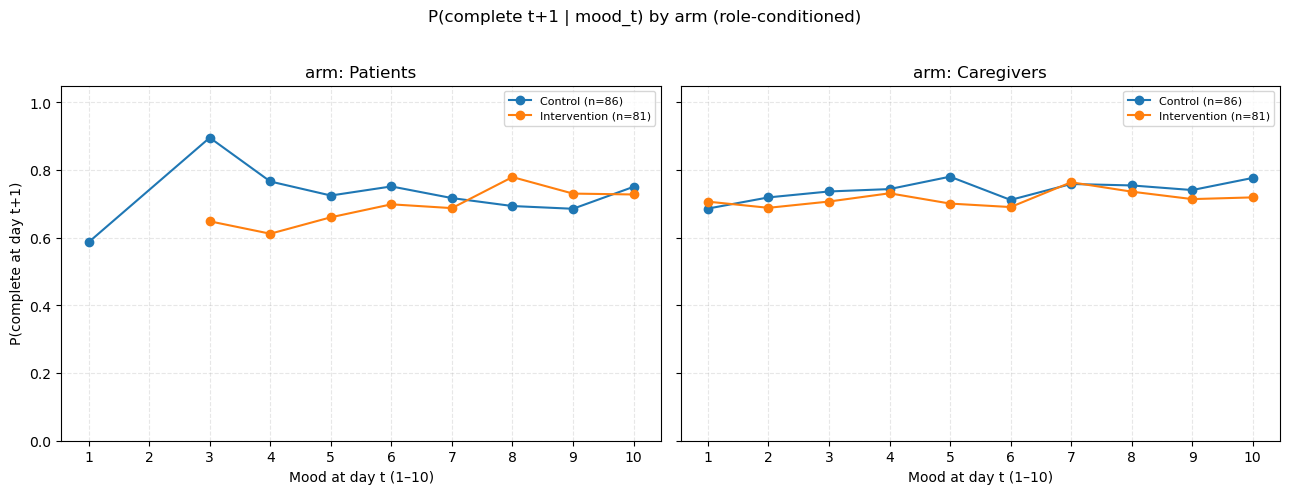

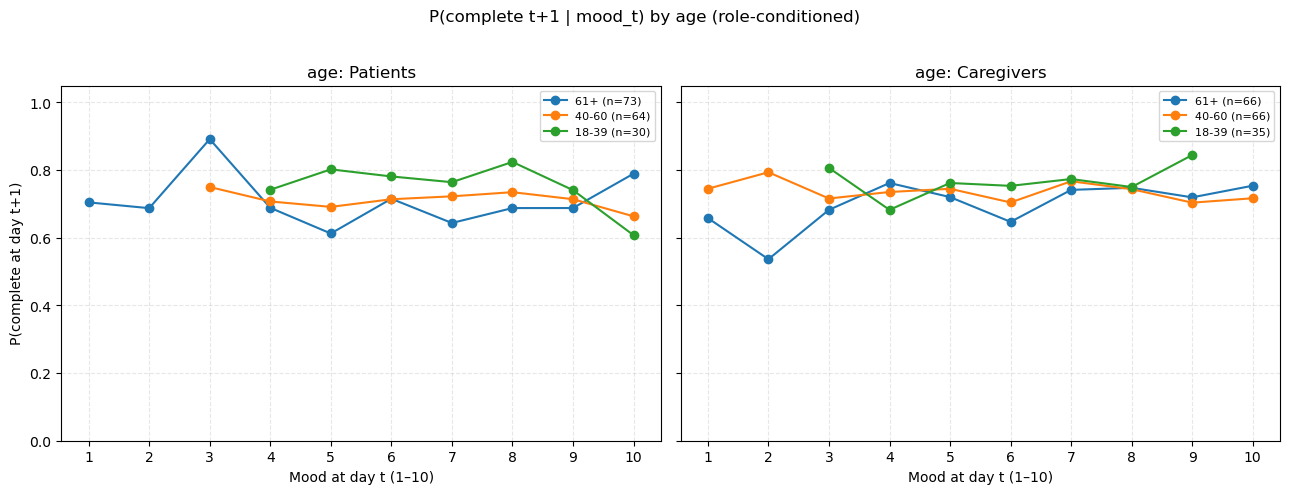

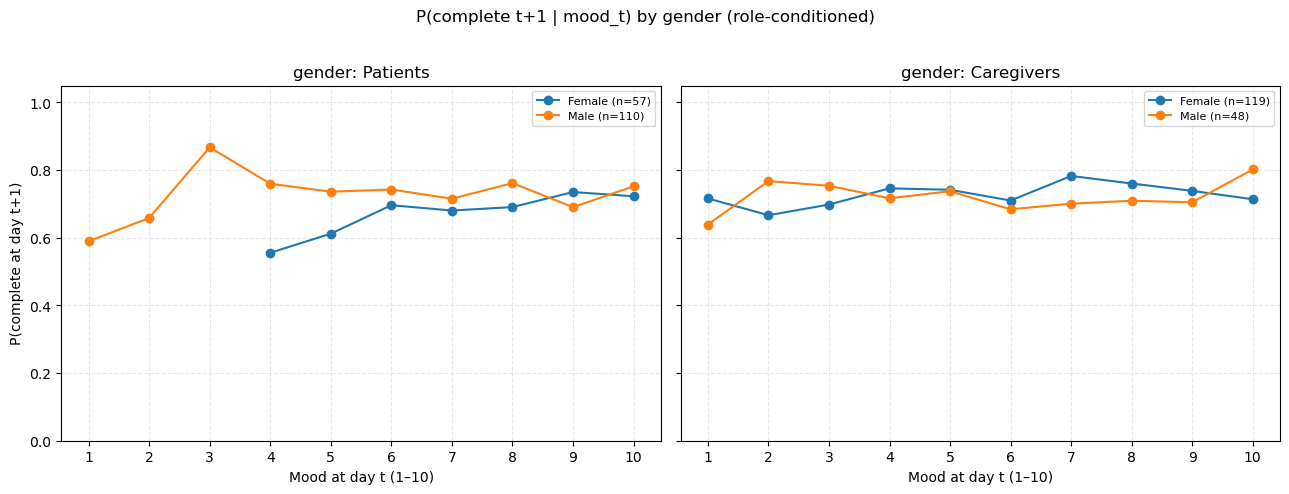

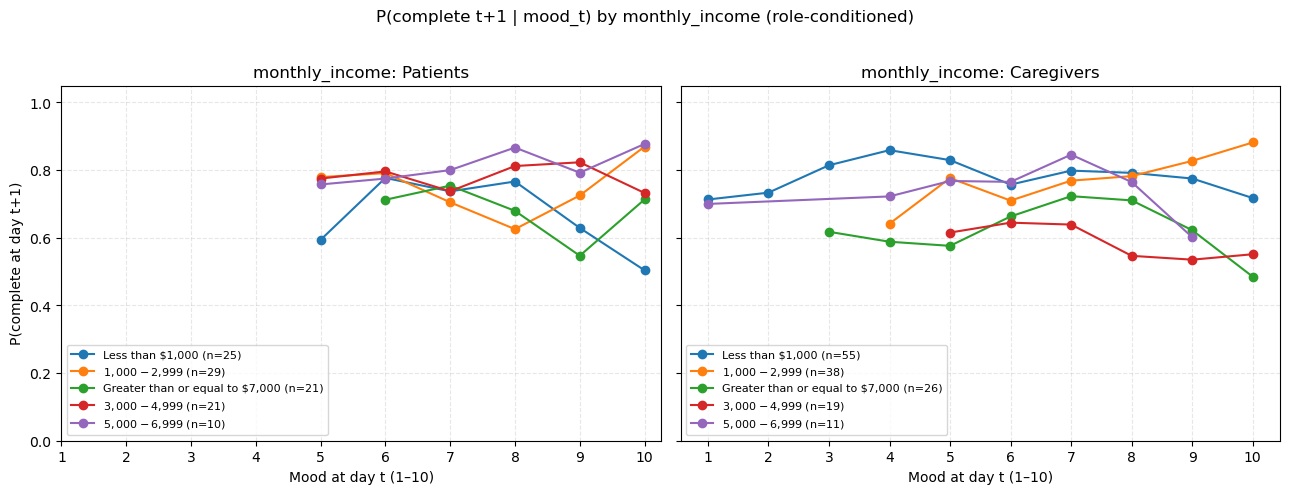

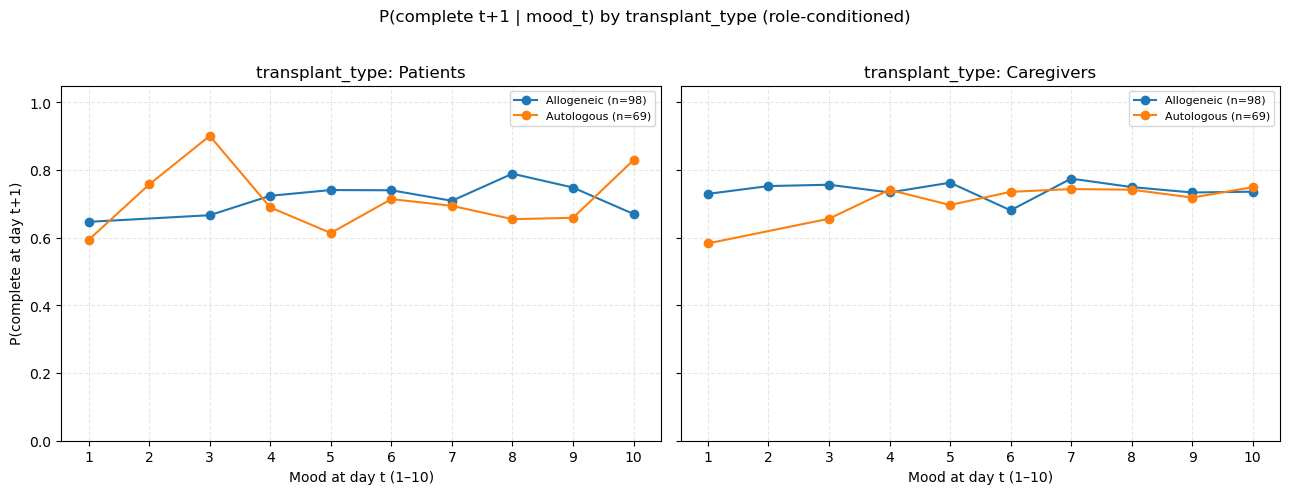

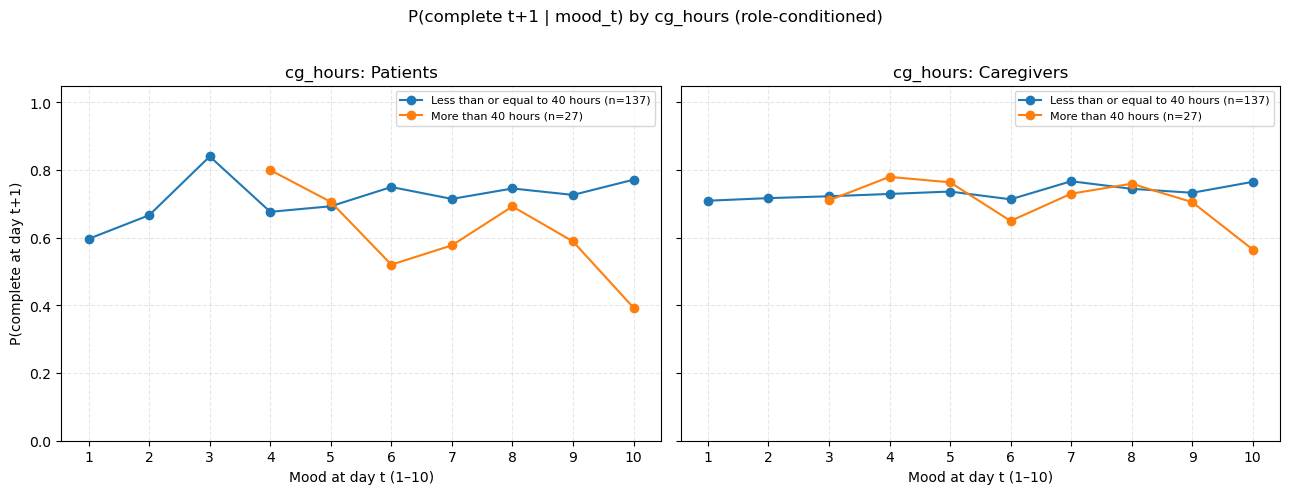

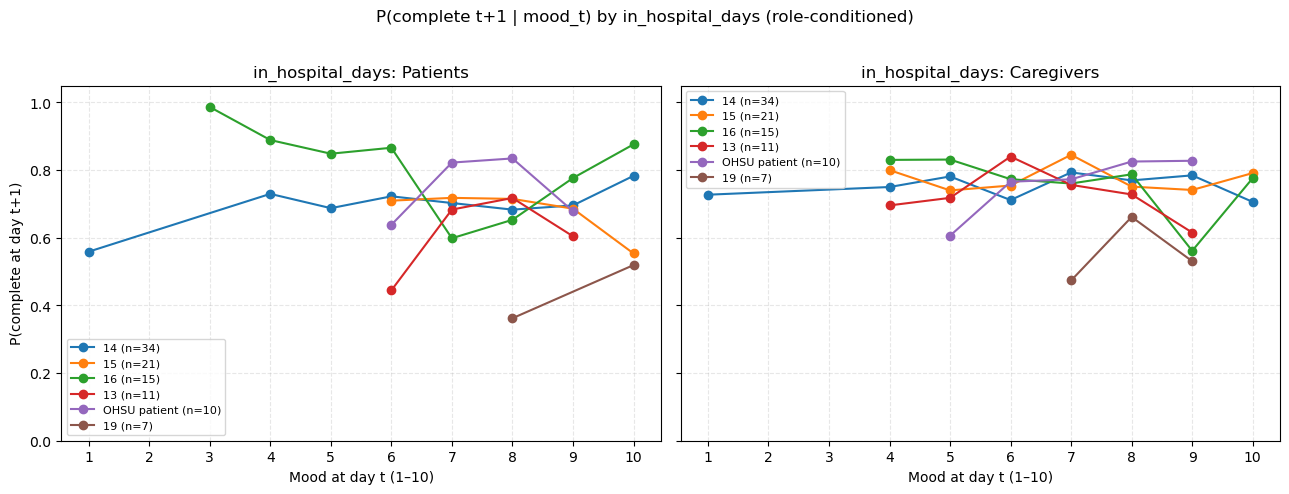

[OK] Preview of stratified conditional probabilities (role-conditioned):


,mood_bin,numerator,denominator,prob_complete_next,demo_field,demo_value,role,n_participants
0,1,170,250,0.680000,ALL,ALL,ALL,NaN
1,2,116,167,0.694611,ALL,ALL,ALL,NaN
2,3,236,308,0.766234,ALL,ALL,ALL,NaN
3,4,403,554,0.727437,ALL,ALL,ALL,NaN
4,5,658,910,0.723077,ALL,ALL,ALL,NaN
5,6,1326,1858,0.713671,ALL,ALL,ALL,NaN
6,7,2216,3001,0.738421,ALL,ALL,ALL,NaN
7,8,3716,5001,0.743051,ALL,ALL,ALL,NaN
8,9,2222,3092,0.718629,ALL,ALL,ALL,NaN
9,10,1405,1898,0.740253,ALL,ALL,ALL,NaN


In [9]:
# %%
# Demographic-stratified P(complete on day t+1 | mood on day t = m), m=1..10
# Data source: participants_data.json
#
# What it does:
#   - Build per-participant day->mood map (restrict to 1..MAX_DAYS if set)
#   - For each demographic field and each category:
#       denom[m] = # of (t with mood_t mapped to m and t+1 within window)
#       numer[m] = # of those with completion at t+1
#       prob[m]  = numer[m] / denom[m]
#   - Plot:
#       (1) A top figure for "role" comparing Patients vs. Caregivers.
#       (2) For every other demographic, two subplots in a single row:
#           left = Patients only, right = Caregivers only.
#   - Export a tidy long table (optional).
#
# Notes:
#   - Mood binning method can be "round"/"floor"/"ceil"
#   - MIN_PARTICIPANTS_PER_CAT filters small categories
#   - MIN_DENOM_PER_POINT hides unreliable points in the plots

import json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

JSON_PATH = "participants_data.json"
MAX_DAYS  = 120            # set None to use all available days
ROUNDING_METHOD = "round"  # "round" | "floor" | "ceil"

# Demographic fields to compare (keys inside node["Demographic"])
DEMOGRAPHIC_FIELDS = [
    "arm",
    "role",
    "age",
    "gender",
    "monthly_income",
    "transplant_type",
    "cg_hours",
    "in_hospital_days",
]

TOP_CATS = 6                   # keep top-N categories by participant count (None = keep all)
MIN_PARTICIPANTS_PER_CAT = 8   # drop categories with fewer participants than this
MIN_DENOM_PER_POINT = 30       # hide points with denominator < this (plotting only)
PLOT_OVERALL = True            # add an overall line as reference

# --------------------
# Load JSON
# --------------------
json_path = Path(JSON_PATH)
if not json_path.exists():
    raise FileNotFoundError(f"JSON not found at: {json_path.resolve()}")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# --------------------
# Helpers
# --------------------
def parse_day_key(k):
    """
    Parse keys like 'Day 4' / 'day 4' / '4' -> int 4. Return None if parsing fails.
    """
    if k is None:
        return None
    s = str(k).strip()
    if s.lower().startswith("day "):
        s = s.split(" ", 1)[1].strip()
    try:
        return int(s)
    except Exception:
        return None

def get_day_to_mood(node, max_days=MAX_DAYS):
    """
    Return {day:int -> mood:float} restricted to 1..max_days if max_days is not None.
    Non-numeric moods are skipped.
    """
    mood_map = node.get("Mood", {}) or {}
    out = {}
    for k, v in mood_map.items():
        d = parse_day_key(k)
        if d is None:
            continue
        if (max_days is not None) and not (1 <= d <= max_days):
            continue
        try:
            mv = float(v)
        except Exception:
            continue
        out[d] = mv
    return out

def mood_to_bin(x, method="round"):
    """
    Map a numeric mood to an integer bin in [1,10] using the specified rounding method.
    Returns None if x is not parseable as a float.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    try:
        xv = float(x)
    except Exception:
        return None
    if method == "floor":
        m = int(np.floor(xv))
    elif method == "ceil":
        m = int(np.ceil(xv))
    else:
        m = int(np.rint(xv))  # nearest int
    return max(1, min(10, m))

MOODS = list(range(1, 11))

def conditional_table_for_pids(pids, pid_day_mood, rounding=ROUNDING_METHOD, max_days=MAX_DAYS):
    """
    Compute P(complete on day t+1 | mood_t in bin m) for the given pid list.
    Returns a DataFrame with columns: mood_bin, numerator, denominator, prob_complete_next.
    """
    numer = {m: 0 for m in MOODS}
    denom = {m: 0 for m in MOODS}

    # Last valid t so that t+1 is in window
    t_upper_limit = None if max_days is None else (max_days - 1)

    for pid in pids:
        day_to_mood = pid_day_mood.get(pid, {})
        if not day_to_mood:
            continue
        days_sorted = sorted(day_to_mood.keys())
        for t in days_sorted:
            if t_upper_limit is not None and t > t_upper_limit:
                continue
            m_bin = mood_to_bin(day_to_mood.get(t, None), method=rounding)
            if m_bin is None:
                continue
            denom[m_bin] += 1
            if (t + 1) in day_to_mood:
                numer[m_bin] += 1

    rows = []
    for m in MOODS:
        d = denom[m]
        n = numer[m]
        p = (n / d) if d > 0 else np.nan
        rows.append({"mood_bin": m, "numerator": n, "denominator": d, "prob_complete_next": p})
    return pd.DataFrame(rows)

def select_categories(field, pid_demo, all_pids):
    """
    Keep categories with at least MIN_PARTICIPANTS_PER_CAT participants,
    then take top-N by frequency if TOP_CATS is set.
    """
    vals = []
    for pid in all_pids:
        v = pid_demo.get(pid, {}).get(field, None)
        if v is not None and v != "":
            vals.append(v)
    cnt = Counter(vals)
    kept = [(cat, c) for cat, c in cnt.items() if c >= MIN_PARTICIPANTS_PER_CAT]
    kept.sort(key=lambda x: x[1], reverse=True)
    if TOP_CATS is not None:
        kept = kept[:TOP_CATS]
    return [cat for cat, _ in kept], cnt

# --------------------
# Build per-pid demographics and mood maps
# --------------------
pid_demo = {}
pid_day_mood = {}
all_pids = []

for pid, node in data.items():
    if not isinstance(node, dict):
        continue
    pid_demo[pid] = node.get("Demographic", {}) or {}
    pid_day_mood[pid] = get_day_to_mood(node, MAX_DAYS)
    all_pids.append(pid)

print(f"[INFO] Participants loaded: {len(all_pids)}")

# Partition by role for conditional plotting
pids_patients   = [pid for pid in all_pids if pid_demo.get(pid, {}).get("role") == "Patients"]
pids_caregivers = [pid for pid in all_pids if pid_demo.get(pid, {}).get("role") == "Caregivers"]

# --------------------
# Overall (pooled) line (all participants)
# --------------------
overall_df = conditional_table_for_pids(all_pids, pid_day_mood)

# --------------------
# 1) Top figure: compare Patients vs. Caregivers (the "role" plot)
# --------------------
role_curves = {
    "Patients":   conditional_table_for_pids(pids_patients, pid_day_mood),
    "Caregivers": conditional_table_for_pids(pids_caregivers, pid_day_mood),
}

plt.figure(figsize=(7.5, 5.0))
if PLOT_OVERALL:
    plt.plot(overall_df["mood_bin"], overall_df["prob_complete_next"],
             marker="o", linewidth=2, label="Overall")

for role_label, dfc in role_curves.items():
    mask = dfc["denominator"] >= MIN_DENOM_PER_POINT
    plt.plot(dfc.loc[mask, "mood_bin"], dfc.loc[mask, "prob_complete_next"],
             marker="o", label=f"{role_label} (n={len(pids_patients) if role_label=='Patients' else len(pids_caregivers)})")

plt.xticks(MOODS)
plt.xlabel("Mood at day t (1–10)")
plt.ylabel("P(complete at day t+1)")
plt.ylim(0, 1.05)
plt.title("P(complete t+1 | mood_t), by role")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="best", fontsize=9)
plt.show()

# --------------------
# 2) For every other demographic, plot two subplots in one row:
#    left = Patients only, right = Caregivers only
# --------------------
for field in DEMOGRAPHIC_FIELDS:
    if field == "role":
        # already plotted above
        continue

    # Select categories (based on *all* participants for that field)
    cats, counter = select_categories(field, pid_demo, all_pids)
    if not cats:
        print(f"[WARN] Skip '{field}' (no categories passing thresholds).")
        continue

    # Prepare per-role PID lists for each category
    def pids_for_category_and_role(category, role_label):
        base = pids_patients if role_label == "Patients" else pids_caregivers
        return [pid for pid in base if pid_demo.get(pid, {}).get(field) == category]

    # Compute curves per category for each role
    curves_pat = {}
    curves_cg  = {}
    sizes_pat  = {}
    sizes_cg   = {}
    for cat in cats:
        p_pat = pids_for_category_and_role(cat, "Patients")
        p_cg  = pids_for_category_and_role(cat, "Caregivers")
        sizes_pat[cat] = len(p_pat)
        sizes_cg[cat]  = len(p_cg)
        curves_pat[cat] = conditional_table_for_pids(p_pat, pid_day_mood)
        curves_cg[cat]  = conditional_table_for_pids(p_cg,  pid_day_mood)

    # Plot two subplots in a single row
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8), sharey=True)
    ax_left, ax_right = axes

    # Left: Patients
    for cat in cats:
        dfc = curves_pat[cat]
        mask = dfc["denominator"] >= MIN_DENOM_PER_POINT
        if mask.any():
            ax_left.plot(dfc.loc[mask, "mood_bin"], dfc.loc[mask, "prob_complete_next"],
                         marker="o", label=f"{cat} (n={sizes_pat[cat]})")
    ax_left.set_title(f"{field}: Patients")
    ax_left.set_xlabel("Mood at day t (1–10)")
    ax_left.set_ylabel("P(complete at day t+1)")
    ax_left.set_xticks(MOODS)
    ax_left.set_ylim(0, 1.05)
    ax_left.grid(True, linestyle="--", alpha=0.3)
    ax_left.legend(loc="best", fontsize=8)

    # Right: Caregivers
    for cat in cats:
        dfc = curves_cg[cat]
        mask = dfc["denominator"] >= MIN_DENOM_PER_POINT
        if mask.any():
            ax_right.plot(dfc.loc[mask, "mood_bin"], dfc.loc[mask, "prob_complete_next"],
                          marker="o", label=f"{cat} (n={sizes_cg[cat]})")
    ax_right.set_title(f"{field}: Caregivers")
    ax_right.set_xlabel("Mood at day t (1–10)")
    ax_right.set_xticks(MOODS)
    ax_right.set_ylim(0, 1.05)
    ax_right.grid(True, linestyle="--", alpha=0.3)
    ax_right.legend(loc="best", fontsize=8)

    fig.suptitle(f"P(complete t+1 | mood_t) by {field} (role-conditioned)", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

# --------------------
# (Optional) Export a tidy table for downstream analysis
# --------------------
rows = []
# Overall
tmp = overall_df.copy()
tmp["demo_field"] = "ALL"
tmp["demo_value"] = "ALL"
tmp["role"] = "ALL"
rows.append(tmp)

# Role (two categories)
for role_label, dfc in role_curves.items():
    rr = dfc.copy()
    rr["demo_field"] = "role"
    rr["demo_value"] = role_label
    rr["role"] = role_label
    rows.append(rr)

# Every other demographic with role conditioning
for field in DEMOGRAPHIC_FIELDS:
    if field == "role":
        continue
    cats, _ = select_categories(field, pid_demo, all_pids)
    for role_label, base_pids in [("Patients", pids_patients), ("Caregivers", pids_caregivers)]:
        for cat in cats:
            pids_cat = [pid for pid in base_pids if pid_demo.get(pid, {}).get(field) == cat]
            dfc = conditional_table_for_pids(pids_cat, pid_day_mood)
            dfc = dfc.assign(demo_field=field, demo_value=cat, role=role_label, n_participants=len(pids_cat))
            rows.append(dfc)

results_long = pd.concat(rows, ignore_index=True)
print("[OK] Preview of stratified conditional probabilities (role-conditioned):")
try:
    display(results_long.head(12))
except Exception:
    print(results_long.head(12))


[INFO] Participants: 334
[OK] Disengage rate computed (10-day lookahead). Preview:


,day,disengaged_count,denominator,disengage_rate
0,10,87,334,0.260479
1,11,87,334,0.260479
2,12,85,334,0.254491
3,13,84,334,0.251497
4,14,87,334,0.260479
5,15,88,334,0.263473
6,16,90,334,0.269461
7,17,92,334,0.275449
8,18,92,334,0.275449
9,19,89,334,0.266467


,day,disengaged_count,denominator,disengage_rate
91,101,137,334,0.410180
92,102,138,334,0.413174
93,103,135,334,0.404192
94,104,139,334,0.416168
95,105,142,334,0.425150
96,106,137,334,0.410180
97,107,136,334,0.407186
98,108,136,334,0.407186
99,109,142,334,0.425150
100,110,140,334,0.419162


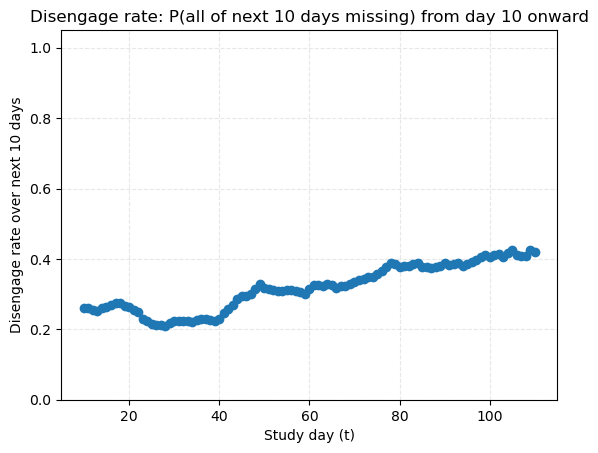

In [10]:
# %%
# Overall 10-day disengage rate from day 10 onward.
# Definition:
#   A participant is "disengaged" at day t if ALL of the next 10 days (t+1 ... t+10)
#   have NO mood record in participants_data.json.
#
# Notes:
#   - We parse mood keys like "Day 7" or "7".
#   - We only evaluate days t where t+10 <= MAX_DAY_TO_CHECK (default: 120),
#     i.e., t in [10, 110].
#   - Denominator per day = total number of participants in the JSON.
#   - Disengage rate(t) = (#disengaged_at_t) / (num_participants).
#
# Output:
#   - A DataFrame with columns: day, disengaged_count, denominator, disengage_rate
#   - A matplotlib line plot of disengage_rate vs day.

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

JSON_PATH = "participants_data.json"
WINDOW = 10                 # lookahead window
START_DAY = 10              # start computing from this day (inclusive)
MAX_DAY_TO_CHECK = 120      # last study day in dataset (inclusive)

# --------------------
# Load JSON
# --------------------
json_path = Path(JSON_PATH)
if not json_path.exists():
    raise FileNotFoundError(f"JSON not found at: {json_path.resolve()}")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# --------------------
# Helpers
# --------------------
def parse_day_key(k):
    """
    Parse keys like 'Day 7' / 'day 7' / '7' -> int 7. Return None if parsing fails.
    """
    if k is None:
        return None
    s = str(k).strip()
    if s.lower().startswith("day "):
        s = s.split(" ", 1)[1].strip()
    try:
        return int(s)
    except Exception:
        return None

def build_mood_day_set(node):
    """
    Return a set of integer days that have a mood entry in the participant node.
    """
    mood_map = node.get("Mood", {}) or {}
    day_set = set()
    for k in mood_map.keys():
        d = parse_day_key(k)
        if d is not None:
            day_set.add(d)
    return day_set

# --------------------
# Collect per-participant mood day sets
# --------------------
pid_daysets = {}
all_pids = []
for pid, node in data.items():
    if not isinstance(node, dict):
        continue
    day_set = build_mood_day_set(node)
    pid_daysets[pid] = day_set
    all_pids.append(pid)

num_participants = len(all_pids)
if num_participants == 0:
    raise SystemExit("No participants found.")

print(f"[INFO] Participants: {num_participants}")

# --------------------
# Compute disengage counts per day
# --------------------
# Only evaluate days t where t+WINDOW <= MAX_DAY_TO_CHECK
last_t = MAX_DAY_TO_CHECK - WINDOW
if last_t < START_DAY:
    raise SystemExit("Configuration yields empty evaluation range.")

days = np.arange(START_DAY, last_t + 1, dtype=int)
disengaged_counts = np.zeros_like(days, dtype=int)
denominator = np.full_like(days, num_participants, dtype=int)

for idx, t in enumerate(days):
    # For each participant, check if ALL of t+1..t+WINDOW are missing
    count = 0
    for pid in all_pids:
        dset = pid_daysets.get(pid, set())
        # Missing in the window if none of the days exist in the mood day set
        # i.e., intersection with {t+1...t+WINDOW} is empty
        window_days = range(t + 1, t + WINDOW + 1)
        has_any = any((d in dset) for d in window_days)
        if not has_any:
            count += 1
    disengaged_counts[idx] = count

disengage_rate = disengaged_counts / denominator

result = pd.DataFrame({
    "day": days,
    "disengaged_count": disengaged_counts,
    "denominator": denominator,
    "disengage_rate": disengage_rate
})

print("[OK] Disengage rate computed (10-day lookahead). Preview:")
try:
    display(result.head(10))
    display(result.tail(10))
except Exception:
    print(result.head(10))
    print(result.tail(10))

# --------------------
# Plot
# --------------------
plt.figure()
plt.plot(result["day"], result["disengage_rate"], marker="o")
plt.xlabel("Study day (t)")
plt.ylabel("Disengage rate over next 10 days")
plt.title("Disengage rate: P(all of next 10 days missing) from day 10 onward")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


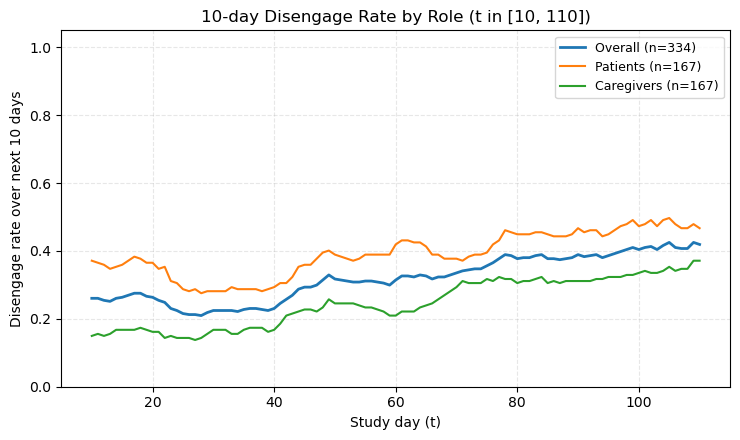

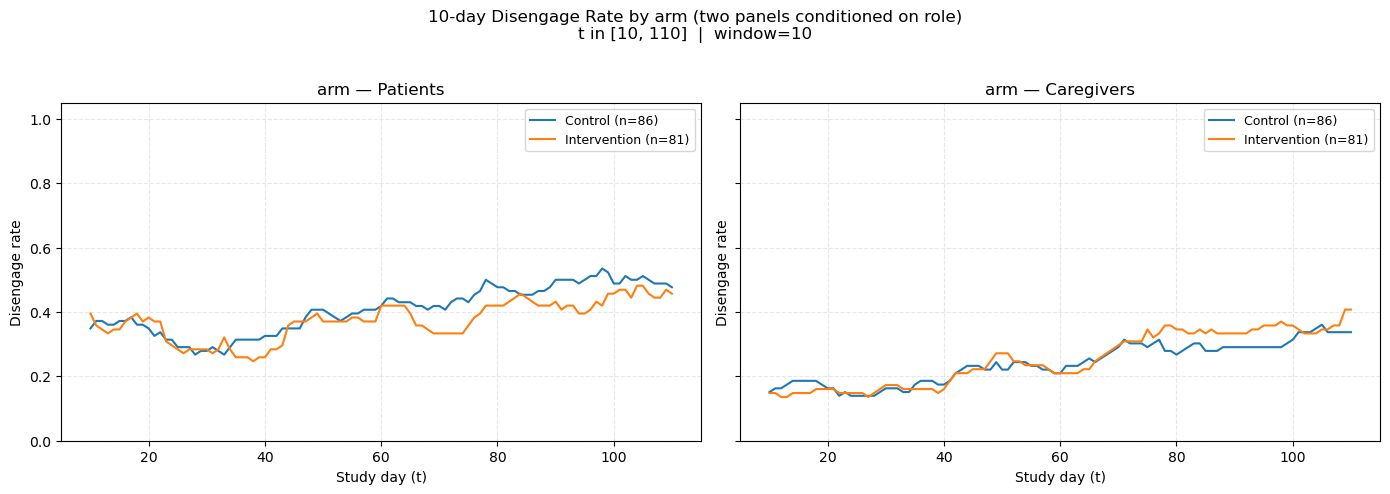

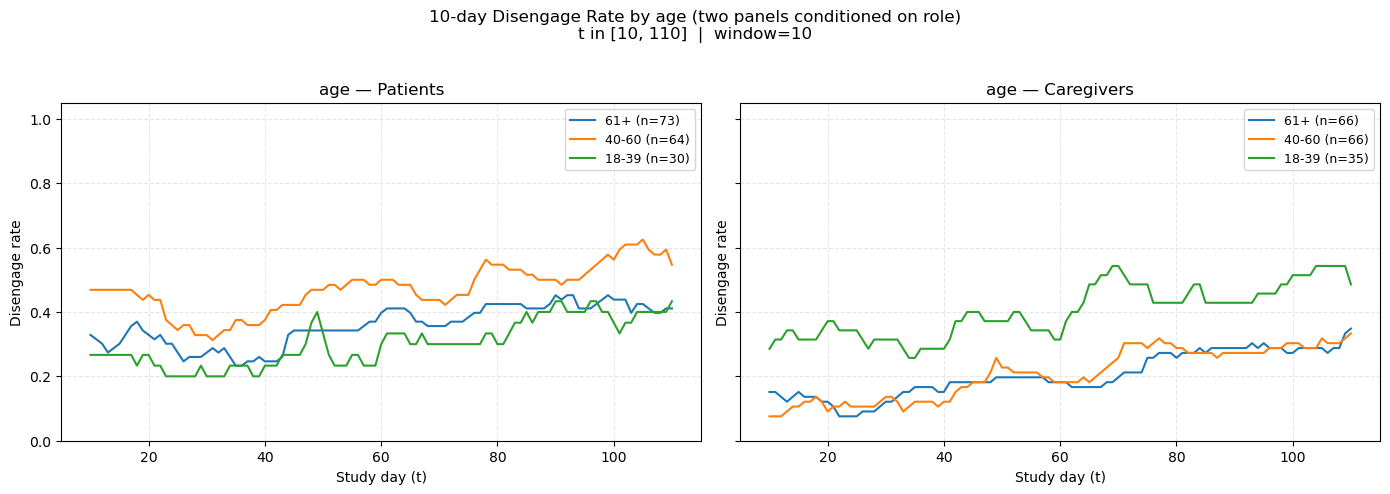

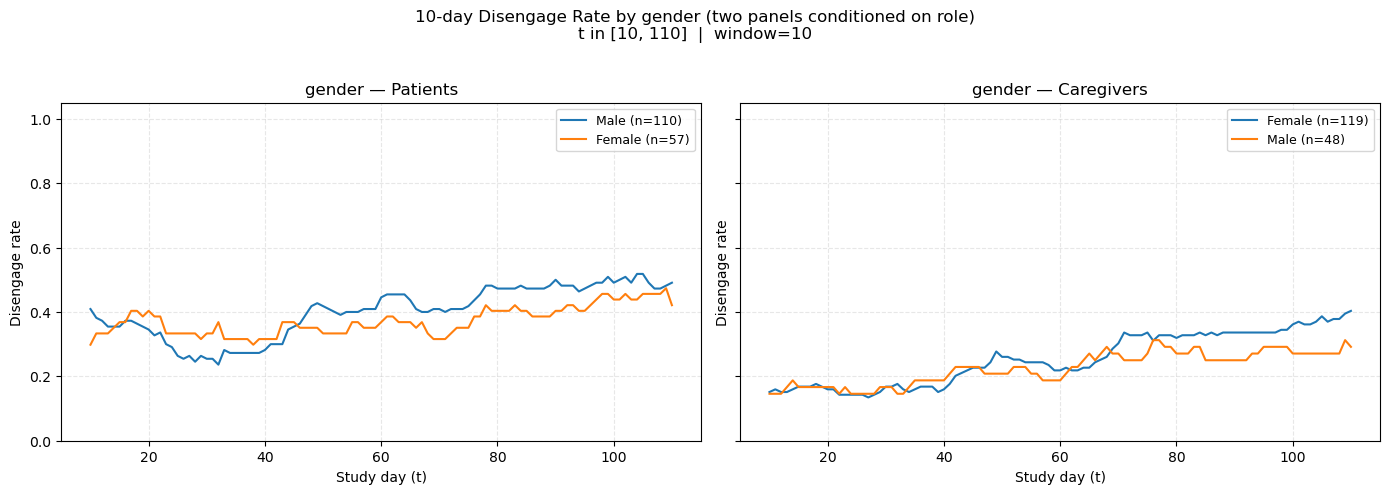

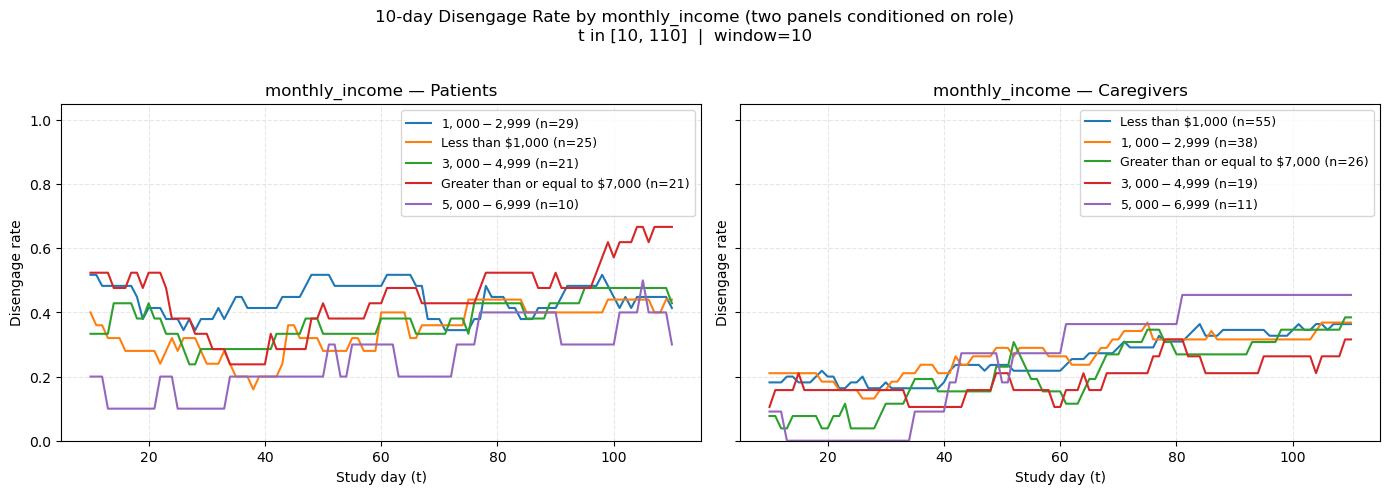

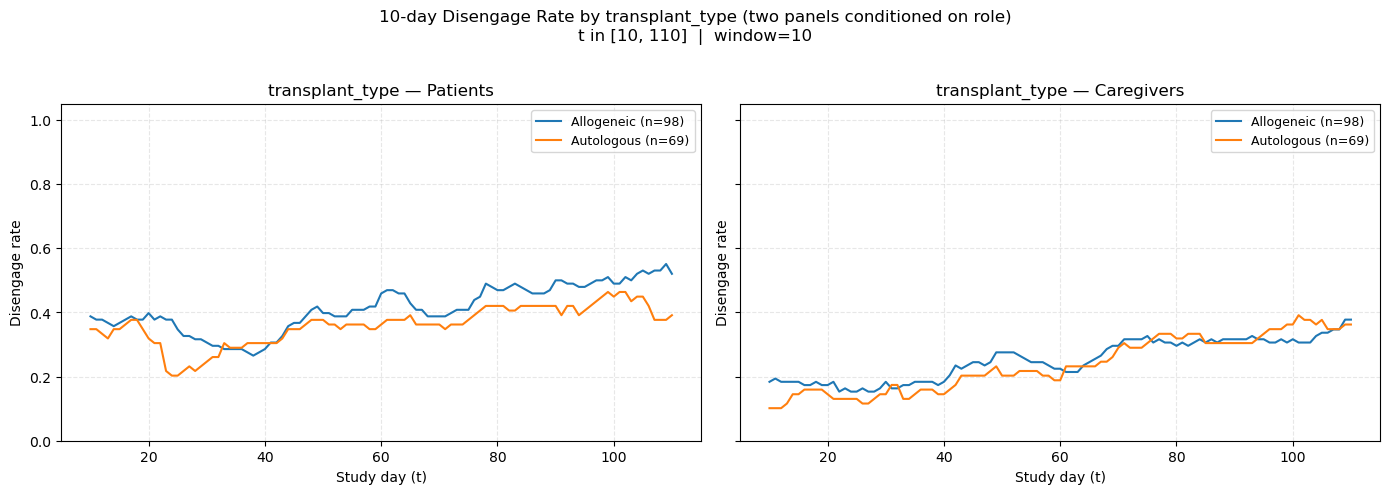

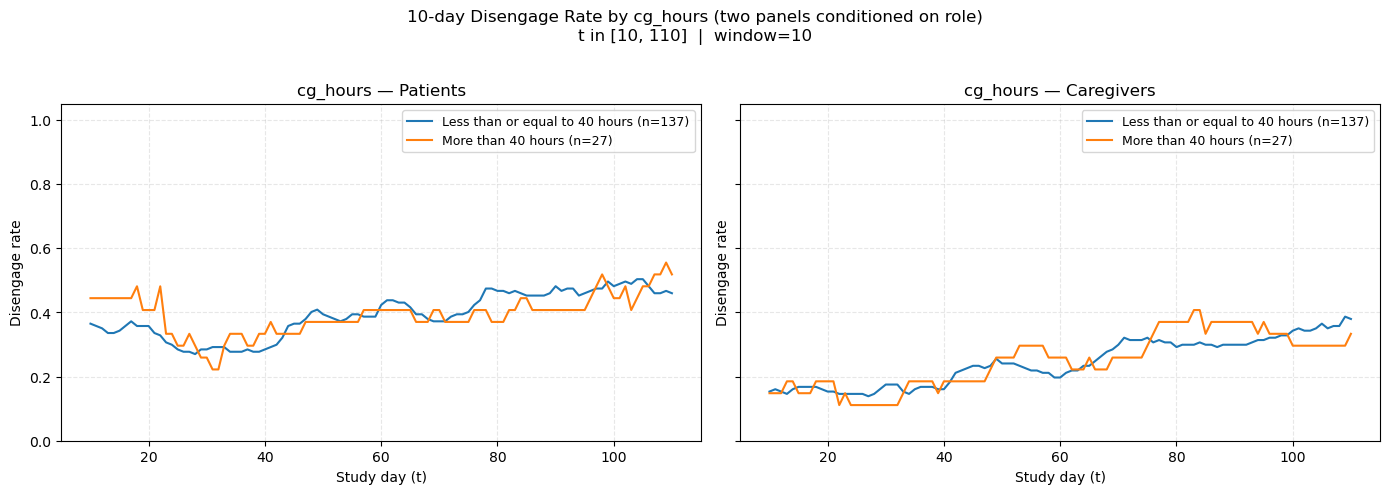

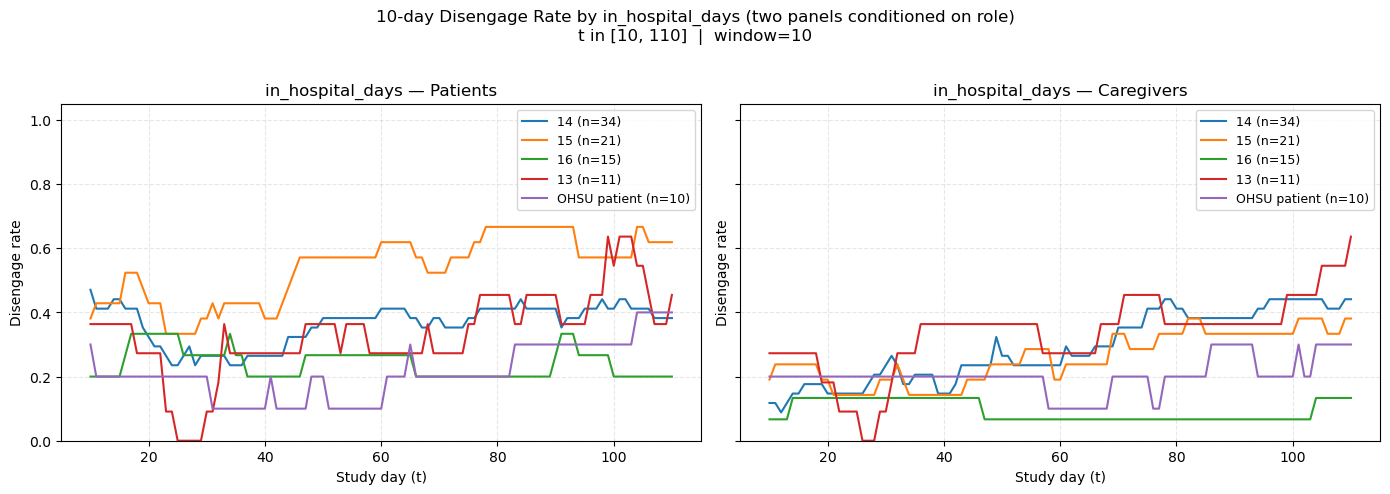

In [12]:
# %%
# Disengage rate over a 10-day lookahead window, stratified by demographics.
# Definition (per participant at day t): "disengaged" if ALL of days (t+1 ... t+10)
#   have NO mood record.
#
# Layout:
#   - Top row: a single figure for role with two lines (Patients vs. Caregivers).
#   - Following rows: for each other demographic field, two subplots in the same row:
#         left  = Patients (multiple lines by categories of that field)
#         right = Caregivers (multiple lines by categories of that field)
#
# Notes:
#   - Keys like "Day 7" are parsed to integers.
#   - We evaluate t in [START_DAY, MAX_DAY_TO_CHECK - WINDOW] so t+WINDOW is valid.
#   - Denominator per curve/day = #participants in that subset (constant over days).
#   - Optional smoothing: set SMOOTH_WINDOW to an integer (e.g., 5) for moving average.
#
# Output:
#   - Summary curve DataFrame per subset.
#   - Matplotlib figures.

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

JSON_PATH = "participants_data.json"

# Window settings
WINDOW = 10
START_DAY = 10
MAX_DAY_TO_CHECK = 120

# Plot category filtering (to keep plots readable)
TOP_CATS = 6                   # keep top-N categories by participant count (None = keep all)
MIN_PARTICIPANTS_PER_CAT = 8   # drop categories with fewer participants
PLOT_OVERALL_IN_ROLE = True    # add overall line on the top role plot

# Optional smoothing (moving average). Set to None to disable.
SMOOTH_WINDOW = None  # e.g., 5 to smooth curves

# Demographic fields to visualize (must exist in node["Demographic"])
DEMOGRAPHIC_FIELDS = [
    "role",             # will be placed at the very top as a single plot with two lines
    "arm",
    "age",
    "gender",
    "monthly_income",
    "transplant_type",
    "cg_hours",
    "in_hospital_days",
]

# --------------------
# Load JSON
# --------------------
json_path = Path(JSON_PATH)
if not json_path.exists():
    raise FileNotFoundError(f"JSON not found at: {json_path.resolve()}")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# --------------------
# Parsing helpers
# --------------------
def parse_day_key(k):
    """Parse keys like 'Day 7' / '7' -> int 7; return None if fail."""
    if k is None:
        return None
    s = str(k).strip()
    if s.lower().startswith("day "):
        s = s.split(" ", 1)[1].strip()
    try:
        return int(s)
    except Exception:
        return None

def mood_day_set(node: dict) -> set:
    """Return a set of integer days that have a mood entry."""
    mood_map = node.get("Mood", {}) or {}
    days = set()
    for k in mood_map.keys():
        d = parse_day_key(k)
        if d is not None:
            days.add(d)
    return days

# --------------------
# Build participant tables
# --------------------
pid_demo = {}
pid_daysets = {}
all_pids = []

for pid, node in data.items():
    if not isinstance(node, dict):
        continue
    demo = node.get("Demographic", {}) or {}
    pid_demo[pid] = demo
    pid_daysets[pid] = mood_day_set(node)
    all_pids.append(pid)

num_participants = len(all_pids)
if num_participants == 0:
    raise SystemExit("No participants found.")

# Valid t range
last_t = MAX_DAY_TO_CHECK - WINDOW
if last_t < START_DAY:
    raise SystemExit("Empty evaluation range; adjust START_DAY / WINDOW / MAX_DAY_TO_CHECK.")

DAYS = np.arange(START_DAY, last_t + 1, dtype=int)

# --------------------
# Core: compute disengage curve for a subset of pids
# --------------------
def disengage_curve_for_pids(pids):
    """
    Return DataFrame with columns:
      day, disengaged_count, denominator, disengage_rate
    """
    if not pids:
        return pd.DataFrame({
            "day": DAYS,
            "disengaged_count": np.zeros_like(DAYS),
            "denominator": np.zeros_like(DAYS),
            "disengage_rate": np.nan
        })
    denom = len(pids)
    counts = np.zeros_like(DAYS, dtype=int)
    for idx, t in enumerate(DAYS):
        win = range(t + 1, t + WINDOW + 1)
        c = 0
        for pid in pids:
            dset = pid_daysets.get(pid, set())
            if not any((d in dset) for d in win):
                c += 1
        counts[idx] = c
    df = pd.DataFrame({
        "day": DAYS,
        "disengaged_count": counts,
        "denominator": denom,
        "disengage_rate": counts / denom if denom > 0 else np.nan
    })
    if SMOOTH_WINDOW and SMOOTH_WINDOW > 1:
        df = df.copy()
        df["disengage_rate_smooth"] = (
            df["disengage_rate"]
            .rolling(window=SMOOTH_WINDOW, min_periods=1, center=True)
            .mean()
        )
    return df

# --------------------
# Utility: choose top categories for a field within a role (optional filtering)
# --------------------
def top_categories_for_field(field, role_value=None):
    """
    Return a list of categories for the given demographic field,
    optionally filtered by a role (Patients/Caregivers).
    Applies MIN_PARTICIPANTS_PER_CAT and TOP_CATS.
    """
    vals = []
    for pid in all_pids:
        if role_value is not None:
            r = pid_demo.get(pid, {}).get("role", None)
            if r != role_value:
                continue
        v = pid_demo.get(pid, {}).get(field, None)
        if v not in (None, ""):
            vals.append(v)
    cnt = Counter(vals)
    items = [(cat, n) for cat, n in cnt.items() if n >= MIN_PARTICIPANTS_PER_CAT]
    items.sort(key=lambda x: x[1], reverse=True)
    if TOP_CATS is not None:
        items = items[:TOP_CATS]
    return [cat for cat, _ in items], cnt

# --------------------
# 1) ROLE plot at the top (two lines)
# --------------------
role_values = ["Patients", "Caregivers"]
role_curves = {}
role_sizes = {}

plt.figure(figsize=(7.5, 4.5))

# Optional overall line (all participants)
if PLOT_OVERALL_IN_ROLE:
    overall_df = disengage_curve_for_pids(all_pids)
    y_overall = overall_df["disengage_rate_smooth"] if "disengage_rate_smooth" in overall_df.columns else overall_df["disengage_rate"]
    plt.plot(overall_df["day"], y_overall, label=f"Overall (n={num_participants})", linewidth=2)

for rv in role_values:
    rpids = [pid for pid in all_pids if pid_demo.get(pid, {}).get("role") == rv]
    role_sizes[rv] = len(rpids)
    df = disengage_curve_for_pids(rpids)
    role_curves[rv] = df
    y = df["disengage_rate_smooth"] if "disengage_rate_smooth" in df.columns else df["disengage_rate"]
    plt.plot(df["day"], y, label=f"{rv} (n={len(rpids)})")

plt.title(f"10-day Disengage Rate by Role (t in [{START_DAY}, {last_t}])")
plt.xlabel("Study day (t)")
plt.ylabel("Disengage rate over next 10 days")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

# --------------------
# 2) For each other demographic field, plot two subplots on the same row:
#    left = Patients, right = Caregivers (lines per category)
# --------------------
for field in DEMOGRAPHIC_FIELDS:
    if field == "role":
        continue  # already plotted

    # Build category lists per role
    cats_pat, cnt_pat = top_categories_for_field(field, role_value="Patients")
    cats_cg , cnt_cg  = top_categories_for_field(field, role_value="Caregivers")

    # Skip if no categories pass thresholds for both roles
    if not cats_pat and not cats_cg:
        print(f"[WARN] Skip '{field}' (no categories pass thresholds for either role).")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
    # Left: Patients
    ax = axes[0]
    if cats_pat:
        for cat in cats_pat:
            pids = [pid for pid in all_pids
                    if pid_demo.get(pid, {}).get("role") == "Patients"
                    and pid_demo.get(pid, {}).get(field) == cat]
            if not pids:
                continue
            df = disengage_curve_for_pids(pids)
            y = df["disengage_rate_smooth"] if "disengage_rate_smooth" in df.columns else df["disengage_rate"]
            ax.plot(df["day"], y, label=f"{cat} (n={len(pids)})")
    ax.set_title(f"{field} — Patients")
    ax.set_xlabel("Study day (t)")
    ax.set_ylabel("Disengage rate")
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.3)
    if cats_pat:
        ax.legend(loc="best", fontsize=9)

    # Right: Caregivers
    ax = axes[1]
    if cats_cg:
        for cat in cats_cg:
            pids = [pid for pid in all_pids
                    if pid_demo.get(pid, {}).get("role") == "Caregivers"
                    and pid_demo.get(pid, {}).get(field) == cat]
            if not pids:
                continue
            df = disengage_curve_for_pids(pids)
            y = df["disengage_rate_smooth"] if "disengage_rate_smooth" in df.columns else df["disengage_rate"]
            ax.plot(df["day"], y, label=f"{cat} (n={len(pids)})")
    ax.set_title(f"{field} — Caregivers")
    ax.set_xlabel("Study day (t)")
    ax.set_ylabel("Disengage rate")
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.3)
    if cats_cg:
        ax.legend(loc="best", fontsize=9)

    fig.suptitle(f"10-day Disengage Rate by {field} (two panels conditioned on role)\n"
                 f"t in [{START_DAY}, {last_t}]  |  window={WINDOW}"
                 + (f"  |  smooth={SMOOTH_WINDOW}" if SMOOTH_WINDOW else ""),
                 y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
